# Model Training Notebook

Input feature file:

```text
/data/projects/TESS-research/feature_extraction/TESS_features.parquet
```

This notebook trains and evaluates:

1. Logistic Regression baseline
2. Random Forest model
3. Feature importance analysis
4. Final held-out test evaluation


## Step 0 — Imports and Configuration

### Goal
Load required Python libraries and define global configuration values.

### Logic
- Use pandas/numpy for data handling.
- Use scikit-learn for splitting, preprocessing, modeling, and evaluation.
- Set the extracted feature parquet as the input.
- Define the target label column as `family`.

### Expected Result
The notebook environment is ready, and all later cells use the same paths and random seed.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_features.parquet")
FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_conditional_detrended_features.parquet")
OutputDir = Path("/data/projects/TESS-research/ml_analytics/output")
if not OutputDir.exists():
    OutputDir.mkdir(parents=True, exist_ok=True)

TargetColumn = "family"
StatusColumn = "FeatureStatus"
RandomState = 42


## Step 1 — Load Feature Table

### Goal
Load all extracted features from `TESS_features.parquet`.

### Logic
- Read the parquet file into a pandas DataFrame.
- Display the shape and the first few rows.

### Expected Result
You should see approximately one row per successfully processed target plus some rows with non-OK status, depending on the feature extraction output.


In [2]:
FeatureDf = pd.read_parquet(FeaturePath)

print(f"Loaded feature table: {FeatureDf.shape[0]} rows, {FeatureDf.shape[1]} columns")
display(FeatureDf.head())

# Data dictionary: data type and brief explanation for each column available in the feature table.
# This is intentionally generated from column names so the notebook stays useful
# even when the feature extractor adds or removes columns later.
def InferColumnRole(ColumnName):
    LowerName = ColumnName.lower()

    if ColumnName == TargetColumn:
        return "Target label"
    if ColumnName == StatusColumn or "status" in LowerName or "error" in LowerName:
        return "Feature extraction / QC metadata"
    if any(Token in LowerName for Token in ["name", "id", "tic", "vsx", "path", "source", "provenance", "quality"]):
        return "Object / provenance metadata"
    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Candidate model feature"
    return "Metadata / non-model column"

def InferColumnExplanation(ColumnName):
    LowerName = ColumnName.lower()

    ExactExplanations = {
        TargetColumn: "Variable-star family used as the supervised-learning target.",
        StatusColumn: "Feature-extraction status; rows marked ok are used for model training.",
        "FeatureError": "Error message captured when feature extraction failed or produced a warning.",
        "Name": "VSX object name.",
        "VSXId": "Identifier from the AAVSO VSX source catalog.",
        "VSXType": "Original VSX variability type before mapping into broader families.",
        "ticId": "TESS Input Catalog identifier associated with the object, when available.",
        "bestTicId": "Selected TIC match used for light-curve retrieval, when available.",
        "lightCurvePath": "Path to the light-curve file used for feature extraction.",
        "rawLightCurvePath": "Path to the raw light-curve file before standardization or processing.",
        "QualityLabel": "Pipeline quality label summarizing whether the light curve appears usable.",
        "Provenance": "Light-curve source such as SPOC, QLP, or TESSCut.",
    }
    if ColumnName in ExactExplanations:
        return ExactExplanations[ColumnName]

    PatternExplanations = [
        (["period"], "Period-related feature, usually derived from Lomb-Scargle or periodicity analysis."),
        (["freq", "frequency"], "Frequency-related feature corresponding to periodic variability search."),
        (["power"], "Periodogram power or relative strength of a periodic signal."),
        (["fap", "falsealarm"], "False-alarm probability or significance estimate for a periodogram peak."),
        (["amp", "amplitude"], "Brightness/flux variation amplitude measurement."),
        (["flux"], "Flux-distribution statistic computed from the light curve."),
        (["mag", "magnitude"], "Magnitude-related statistic, if magnitude values are present."),
        (["mean", "avg"], "Central-tendency statistic."),
        (["median"], "Robust central-tendency statistic."),
        (["std", "sigma"], "Scatter/noise or variability-width statistic."),
        (["var"], "Variance or variability-strength statistic."),
        (["skew"], "Asymmetry statistic of the flux distribution."),
        (["kurt"], "Tail/heavy-outlier statistic of the flux distribution."),
        (["min", "max", "range"], "Extreme-value or range statistic."),
        (["percentile", "quantile", "p05", "p10", "p25", "p75", "p90", "p95"], "Percentile/quantile statistic describing the light-curve distribution."),
        (["count", "num", "n_", "rows", "cadence"], "Count or cadence-coverage feature."),
        (["trend", "slope", "drift"], "Long-term trend or slope-related diagnostic."),
        (["quality", "mask", "finite", "nan"], "Light-curve quality, missingness, or valid-point diagnostic."),
        (["ra", "dec"], "Sky-coordinate metadata; useful for tracing objects but usually not a physical classifier feature."),
        (["sector"], "TESS sector coverage metadata."),
    ]

    for Keywords, Explanation in PatternExplanations:
        if any(Keyword in LowerName for Keyword in Keywords):
            return Explanation

    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Numeric/bool feature produced by the feature-extraction pipeline; inspect distribution and importance before interpretation."
    return "Metadata column used for tracing, filtering, or joining records rather than direct model training."

FeatureDictionaryDf = pd.DataFrame({
    "Column": FeatureDf.columns,
    "DataType": [str(FeatureDf[Col].dtype) for Col in FeatureDf.columns],
    "Role": [InferColumnRole(Col) for Col in FeatureDf.columns],
    "BriefExplanation": [InferColumnExplanation(Col) for Col in FeatureDf.columns],
})

print("Data dictionary: data type and brief explanation for each column")
display(FeatureDictionaryDf)


Loaded feature table: 7370 rows, 67 columns


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxMean,FluxStd,FluxVariance,FluxMedian,FluxMad,FluxMin,FluxMax,FluxP01,FluxP05,FluxP10,FluxP25,FluxP75,FluxP90,FluxP95,FluxP99,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsBestFrequency,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta
0,ok,NaN,CEPHEID,DCEP,LMC V0827,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_s...,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_r...,acceptable,1.0,TESSCut,2.0,1.0,1.074691,0.930500,True,True,293319.0,2720.548082,0.002315,0.182296,1.0,1.0,0.0,0.014218,-8.059426,21.666578,-2.226746,-0.421401,-0.050117,-0.007363,0.106323,0.699204,1.603927,4.048967,0.113686,29.726005,2.025327,0.749321,5.143412,72.580950,1.603927,0.421401,1.182526,3.806182,0.461728,5234.501410,0.002714,0.101613,0.048258,13.908343,0.071899,0.022761,0.000000e+00,13.901236,13.588779,0.022426,0.021828,0.985314,0.959047,0.999489,0.977024,0.001356,0.004517,0.000794,0.024824,0.674974,0.349851
1,ok,NaN,CEPHEID,DCEP,OGLE-GD-CEP-0948,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_S...,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_S...,clean,0.0,SPOC,0.0,1.0,0.523226,1.911220,True,True,17563.0,25.968380,0.001389,-0.380000,1.0,1.0,0.0,0.233236,-4.275680,0.817094,-3.834142,-3.175055,-1.844262,-0.474010,0.180536,0.300452,0.371343,0.493608,0.654547,5.092774,3.546398,2.144714,-2.173310,3.958710,0.371343,3.175055,-2.803712,0.116957,0.023459,454.889912,0.103308,0.119683,0.080339,0.477262,2.095283,0.446469,0.000000e+00,0.478141,0.476387,0.445210,0.418312,0.997181,0.936934,1.001841,0.998166,0.763762,3.282615,0.663933,0.025031,0.525033,0.499998
2,ok,NaN,CEPHEID,DCEP,ZTF J212148.91+495425.9,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_6371...,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_6371...,clean,0.0,QLP,1.0,1.0,0.159239,6.279885,False,False,1183.0,26.001136,0.020834,0.102400,1.0,1.0,0.0,0.593655,-3.503968,5.789540,-1.726929,-1.130794,-0.962205,-0.565363,0.607883,1.158703,1.852841,3.475937,1.173246,9.293508,2.983636,2.120908,1.105766,3.686204,1.852841,1.130794,0.722047,1.638531,0.205346,124.626716,0.181267,0.227388,0.046492,3.817459,0.261954,0.259213,5.871473e-73,3.874341,3.762222,0.253059,0.251654,0.976259,0.970840,1.014901,0.985531,0.568332,1.894740,0.281162,0.774336,0.374676,0.399660
3,failed,"TypeError(""unsupported operand type(s) for /: ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,failed,"TypeError(""unsupported operand type(s) for /: ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data dictionary: data type and brief explanation for each column


,Column,DataType,Role,BriefExplanation
0,FeatureStatus,str,Feature extraction / QC metadata,Feature-extraction status; rows marked ok are ...
1,FeatureError,str,Feature extraction / QC metadata,Error message captured when feature extraction...
2,family,str,Target label,Variable-star family used as the supervised-le...
3,VSXType,str,Object / provenance metadata,Original VSX variability type before mapping i...
4,VSXId,str,Object / provenance metadata,Identifier from the AAVSO VSX source catalog.
...,...,...,...,...
62,PhaseCurveRange,float64,Candidate model feature,Extreme-value or range statistic.
63,PhaseCurveSmoothness,float64,Candidate model feature,Numeric/bool feature produced by the feature-e...
64,PhasePeakPhase,float64,Candidate model feature,Numeric/bool feature produced by the feature-e...
65,PhaseTroughPhase,float64,Candidate model feature,Numeric/bool feature produced by the feature-e...


## Step 2 — Check Feature Extraction Status

### Goal
Confirm which rows are usable for model training.

### Logic
- Count values in `FeatureStatus`.
- Keep only rows where `FeatureStatus == "ok"`.
- Drop rows with missing target label.

### Expected Result
Most rows should be `ok`. Rows with `missing_lightcurve_path` or failed extraction should be excluded from modeling.


In [3]:
if StatusColumn in FeatureDf.columns:
    display(FeatureDf[StatusColumn].value_counts(dropna=False))
    ModelDf = FeatureDf[FeatureDf[StatusColumn] == "ok"].copy()
else:
    print(f"Warning: {StatusColumn} not found; using all rows.")
    ModelDf = FeatureDf.copy()

ModelDf = ModelDf.dropna(subset=[TargetColumn]).copy()

print(f"Rows available for modeling: {len(ModelDf)}")
display(ModelDf[TargetColumn].value_counts())


FeatureStatus
ok        7113
failed     257
Name: count, dtype: int64

Rows available for modeling: 7113


family
ELLIPSOIDAL_ROT    997
ECLIPSING          996
LONG_PERIOD        980
RRLYR              976
DSCT_SXPHE         953
CEPHEID            836
YSO                724
CV                 595
XRAY                56
Name: count, dtype: int64

## Step 2.5 — Add Enhanced Lomb–Scargle Period Features

### Goal
Improve the feature table by adding richer period-related features instead of relying only on the single best Lomb–Scargle period.

### Logic
- Keep the existing best-period features if they already exist.
- Add normalized top-peak fields for the first three Lomb–Scargle peaks:
  - `LsTopPeriod1`, `LsTopPeriod2`, `LsTopPeriod3`
  - `LsTopPower1`, `LsTopPower2`, `LsTopPower3`
  - `LsTopFrequency1`, `LsTopFrequency2`, `LsTopFrequency3`
- Add period and power ratios:
  - `LsPeriodRatio21`, `LsPeriodRatio31`
  - `LsPowerRatio21`, `LsPowerRatio31`
- Add false-alarm-probability transformations:
  - `LsFalseAlarmProbability`
  - `LsLogFalseAlarmProbability`
  - `LsNegativeLog10FalseAlarmProbability`
- If second/third peak columns are not already present, optionally recompute the top peaks from the light-curve FITS files.

### Expected Result
The model receives more information about harmonic/alias structure. This should help separate variable-star families whose single best periods may overlap or be affected by harmonics.


In [4]:
# Improvement 1: richer period-related feature engineering.
# These features are added before feature selection so both Logistic Regression
# and Random Forest can use them.

RecomputeMissingLsPeaks = True
LsPeakCachePath = OutputDir / "enhanced_lomb_scargle_peak_features.parquet"


def _safeDivide(Numerator, Denominator):
    Numerator = pd.to_numeric(Numerator, errors="coerce")
    Denominator = pd.to_numeric(Denominator, errors="coerce")
    return np.where(np.isfinite(Denominator) & (Denominator != 0), Numerator / Denominator, np.nan)


def _firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def _readLightCurveFromFits(LightCurvePath):
    """Read a light curve from a FITS file using flexible column-name matching."""
    from astropy.io import fits

    if pd.isna(LightCurvePath):
        return None, None

    PathObj = Path(str(LightCurvePath))
    if not PathObj.exists():
        return None, None

    with fits.open(PathObj, memmap=True) as Hdul:
        for Hdu in Hdul:
            Data = getattr(Hdu, "data", None)
            if Data is None or not hasattr(Data, "names") or Data.names is None:
                continue

            NameMap = {Name.upper(): Name for Name in Data.names}
            TimeCol = None
            for Candidate in ["TIME", "BTJD", "BJD", "JD"]:
                if Candidate in NameMap:
                    TimeCol = NameMap[Candidate]
                    break

            FluxCol = None
            for Candidate in ["PDCSAP_FLUX", "SAP_FLUX", "KSPSAP_FLUX", "FLUX", "RAW_FLUX"]:
                if Candidate in NameMap:
                    FluxCol = NameMap[Candidate]
                    break

            if TimeCol is not None and FluxCol is not None:
                Time = np.asarray(Data[TimeCol], dtype=float)
                Flux = np.asarray(Data[FluxCol], dtype=float)
                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]
                if len(Time) >= 30:
                    return Time, Flux

    return None, None


def _computeTopLombScarglePeaksForPath(LightCurvePath):
    """Compute top 3 separated Lomb-Scargle peaks for one light curve."""
    try:
        from astropy.timeseries import LombScargle
    except Exception:
        return {}

    try:
        Time, Flux = _readLightCurveFromFits(LightCurvePath)
        if Time is None or Flux is None or len(Time) < 30:
            return {}

        # Sort and normalize to make the periodogram more stable.
        Order = np.argsort(Time)
        Time = Time[Order]
        Flux = Flux[Order]
        Time = Time - np.nanmin(Time)

        FluxMedian = np.nanmedian(Flux)
        FluxStd = np.nanstd(Flux)
        if not np.isfinite(FluxStd) or FluxStd <= 0:
            return {}
        if np.isfinite(FluxMedian) and abs(FluxMedian) > 0:
            Flux = (Flux - FluxMedian) / FluxStd
        else:
            Flux = (Flux - np.nanmean(Flux)) / FluxStd

        Baseline = np.nanmax(Time) - np.nanmin(Time)
        Cadence = np.nanmedian(np.diff(np.unique(Time)))
        if not np.isfinite(Baseline) or Baseline <= 0 or not np.isfinite(Cadence) or Cadence <= 0:
            return {}

        # Conservative frequency range in cycles/day.
        # The upper cap avoids chasing very high-cadence noise.
        MinimumFrequency = max(1.0 / Baseline, 0.01)
        MaximumFrequency = min(0.5 / Cadence, 24.0)
        if MaximumFrequency <= MinimumFrequency:
            return {}

        Ls = LombScargle(Time, Flux, normalization="standard")
        Frequency, Power = Ls.autopower(
            minimum_frequency=MinimumFrequency,
            maximum_frequency=MaximumFrequency,
            samples_per_peak=5,
        )

        if len(Power) == 0 or not np.isfinite(Power).any():
            return {}

        # Select local maxima when scipy is available; otherwise fall back to top powers.
        try:
            from scipy.signal import find_peaks
            PeakIndices, _ = find_peaks(Power, distance=5)
            if len(PeakIndices) == 0:
                PeakIndices = np.arange(len(Power))
        except Exception:
            PeakIndices = np.arange(len(Power))

        PeakIndices = PeakIndices[np.argsort(Power[PeakIndices])[::-1]]
        PeakIndices = PeakIndices[:3]

        Result = {}
        for Rank in range(1, 4):
            if Rank <= len(PeakIndices):
                Idx = PeakIndices[Rank - 1]
                Freq = float(Frequency[Idx])
                Pow = float(Power[Idx])
                Result[f"LsTopFrequency{Rank}"] = Freq
                Result[f"LsTopPeriod{Rank}"] = 1.0 / Freq if Freq > 0 else np.nan
                Result[f"LsTopPower{Rank}"] = Pow
            else:
                Result[f"LsTopFrequency{Rank}"] = np.nan
                Result[f"LsTopPeriod{Rank}"] = np.nan
                Result[f"LsTopPower{Rank}"] = np.nan

        BestPower = Result.get("LsTopPower1", np.nan)
        try:
            Result["LsFalseAlarmProbability"] = float(Ls.false_alarm_probability(BestPower)) if np.isfinite(BestPower) else np.nan
        except Exception:
            Result["LsFalseAlarmProbability"] = np.nan

        return Result
    except Exception:
        return {}


def _computeLsPeakCache(Df):
    LightCurvePathCol = _firstExistingColumn(Df, ["lightCurvePath", "rawLightCurvePath", "LightCurvePath", "RawLightCurvePath"])
    if LightCurvePathCol is None:
        print("No light-curve path column found; using only existing Lomb-Scargle columns.")
        return pd.DataFrame()

    UniquePaths = pd.Series(Df[LightCurvePathCol].dropna().astype(str).unique(), name=LightCurvePathCol)
    if len(UniquePaths) == 0:
        return pd.DataFrame()

    if LsPeakCachePath.exists():
        CacheDf = pd.read_parquet(LsPeakCachePath)
        CachedPaths = set(CacheDf[LightCurvePathCol].astype(str)) if LightCurvePathCol in CacheDf.columns else set()
    else:
        CacheDf = pd.DataFrame(columns=[LightCurvePathCol])
        CachedPaths = set()

    MissingPaths = [PathStr for PathStr in UniquePaths if PathStr not in CachedPaths]

    if RecomputeMissingLsPeaks and MissingPaths:
        print(f"Computing enhanced Lomb-Scargle top-peak features for {len(MissingPaths)} light curves not found in cache...")
        Records = []
        for PathStr in MissingPaths:
            Rec = {LightCurvePathCol: PathStr}
            Rec.update(_computeTopLombScarglePeaksForPath(PathStr))
            Records.append(Rec)
        NewCacheDf = pd.DataFrame(Records)
        CacheDf = pd.concat([CacheDf, NewCacheDf], ignore_index=True)
        CacheDf = CacheDf.drop_duplicates(subset=[LightCurvePathCol], keep="last")
        CacheDf.to_parquet(LsPeakCachePath, index=False)
        print(f"Saved Lomb-Scargle peak cache: {LsPeakCachePath}")
    elif MissingPaths:
        print(f"{len(MissingPaths)} light curves are missing from the LS peak cache; recomputation is disabled.")

    return CacheDf


def addEnhancedPeriodFeatures(Df):
    """Add top-peak, ratio, and FAP-transformed period features to a dataframe."""
    Df = Df.copy()

    # Normalize existing best-period columns into a consistent Top1 naming scheme.
    ExistingMappings = {
        "LsTopPeriod1": ["LsTopPeriod1", "LsBestPeriod"],
        "LsTopFrequency1": ["LsTopFrequency1", "LsBestFrequency"],
        "LsTopPower1": ["LsTopPower1", "LsMaxPower"],
        "LsTopPeriod2": ["LsTopPeriod2", "LsPeriod2"],
        "LsTopPeriod3": ["LsTopPeriod3", "LsPeriod3"],
        "LsTopPower2": ["LsTopPower2", "LsPower2"],
        "LsTopPower3": ["LsTopPower3", "LsPower3"],
    }

    for TargetCol, Candidates in ExistingMappings.items():
        SourceCol = _firstExistingColumn(Df, Candidates)
        if SourceCol is not None:
            Df[TargetCol] = pd.to_numeric(Df[SourceCol], errors="coerce")

    # Derive frequencies from periods when needed.
    for Rank in [1, 2, 3]:
        PeriodCol = f"LsTopPeriod{Rank}"
        FreqCol = f"LsTopFrequency{Rank}"
        if PeriodCol in Df.columns and FreqCol not in Df.columns:
            Df[FreqCol] = _safeDivide(1.0, Df[PeriodCol])

    # If top 2/3 peaks are still missing, merge computed peak features from cache/path.
    MissingTopPeakCols = [Col for Col in ["LsTopPeriod2", "LsTopPeriod3", "LsTopPower2", "LsTopPower3"] if Col not in Df.columns]
    if MissingTopPeakCols:
        LightCurvePathCol = _firstExistingColumn(Df, ["lightCurvePath", "rawLightCurvePath", "LightCurvePath", "RawLightCurvePath"])
        CacheDf = _computeLsPeakCache(Df)
        if LightCurvePathCol is not None and not CacheDf.empty and LightCurvePathCol in CacheDf.columns:
            MergeCols = [LightCurvePathCol] + [Col for Col in CacheDf.columns if Col.startswith("LsTop") or Col == "LsFalseAlarmProbability"]
            Df = Df.merge(CacheDf[MergeCols], how="left", on=LightCurvePathCol, suffixes=("", "_computed"))
            for Col in ["LsTopFrequency1", "LsTopFrequency2", "LsTopFrequency3", "LsTopPeriod1", "LsTopPeriod2", "LsTopPeriod3", "LsTopPower1", "LsTopPower2", "LsTopPower3", "LsFalseAlarmProbability"]:
                ComputedCol = f"{Col}_computed"
                if ComputedCol in Df.columns:
                    if Col in Df.columns:
                        Df[Col] = Df[Col].combine_first(Df[ComputedCol])
                    else:
                        Df[Col] = Df[ComputedCol]
                    Df.drop(columns=[ComputedCol], inplace=True)

    # Ratios and peak-structure features.
    if {"LsTopPeriod1", "LsTopPeriod2"}.issubset(Df.columns):
        Df["LsPeriodRatio21"] = _safeDivide(Df["LsTopPeriod2"], Df["LsTopPeriod1"])
    if {"LsTopPeriod1", "LsTopPeriod3"}.issubset(Df.columns):
        Df["LsPeriodRatio31"] = _safeDivide(Df["LsTopPeriod3"], Df["LsTopPeriod1"])
    if {"LsTopFrequency1", "LsTopFrequency2"}.issubset(Df.columns):
        Df["LsFrequencyRatio21"] = _safeDivide(Df["LsTopFrequency2"], Df["LsTopFrequency1"])
    if {"LsTopFrequency1", "LsTopFrequency3"}.issubset(Df.columns):
        Df["LsFrequencyRatio31"] = _safeDivide(Df["LsTopFrequency3"], Df["LsTopFrequency1"])
    if {"LsTopPower1", "LsTopPower2"}.issubset(Df.columns):
        Df["LsPowerRatio21"] = _safeDivide(Df["LsTopPower2"], Df["LsTopPower1"])
        Df["LsPeakPowerGap12"] = pd.to_numeric(Df["LsTopPower1"], errors="coerce") - pd.to_numeric(Df["LsTopPower2"], errors="coerce")
    if {"LsTopPower1", "LsTopPower3"}.issubset(Df.columns):
        Df["LsPowerRatio31"] = _safeDivide(Df["LsTopPower3"], Df["LsTopPower1"])
    if {"LsTopPower2", "LsTopPower3"}.issubset(Df.columns):
        Df["LsPeakPowerGap23"] = pd.to_numeric(Df["LsTopPower2"], errors="coerce") - pd.to_numeric(Df["LsTopPower3"], errors="coerce")

    # False-alarm probability transformations.  Smaller FAP means stronger periodic evidence;
    # -log10(FAP) makes this easier for models to use.
    if "LsFalseAlarmProbability" in Df.columns:
        Fap = pd.to_numeric(Df["LsFalseAlarmProbability"], errors="coerce").clip(lower=1e-300, upper=1.0)
        Df["LsLogFalseAlarmProbability"] = np.log(Fap)
        Df["LsNegativeLog10FalseAlarmProbability"] = -np.log10(Fap)
        Df["LsHasReliableFap"] = np.isfinite(Fap).astype(int)

    return Df


ModelDf = addEnhancedPeriodFeatures(ModelDf)

EnhancedPeriodFeatureColumns = [
    Col for Col in ModelDf.columns
    if Col.startswith("LsTop")
    or Col.startswith("LsPeriodRatio")
    or Col.startswith("LsFrequencyRatio")
    or Col.startswith("LsPowerRatio")
    or Col.startswith("LsPeakPowerGap")
    or Col in ["LsLogFalseAlarmProbability", "LsNegativeLog10FalseAlarmProbability", "LsHasReliableFap"]
]

print(f"Enhanced period-related features available: {len(EnhancedPeriodFeatureColumns)}")
display(ModelDf[EnhancedPeriodFeatureColumns].head())


Enhanced period-related features available: 20


,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,LsTopPeriod1,LsTopFrequency1,LsTopPower1,LsTopPeriod2,LsTopPeriod3,LsTopPower2,LsTopPower3,LsTopFrequency2,LsTopFrequency3,LsFrequencyRatio21,LsFrequencyRatio31,LsPeakPowerGap12,LsPeakPowerGap23,LsLogFalseAlarmProbability,LsNegativeLog10FalseAlarmProbability,LsHasReliableFap
0,0.985314,0.959047,0.999489,0.977024,13.908343,0.071899,0.022761,13.901236,13.588779,0.022426,0.021828,0.071936,0.073590,1.000511,1.023517,0.000334,0.000598,-690.775528,300.000000,1
1,0.997181,0.936934,1.001841,0.998166,0.477262,2.095283,0.446469,0.478141,0.476387,0.445210,0.418312,2.091432,2.099134,0.998162,1.001838,0.001259,0.026898,-690.775528,300.000000,1
2,0.976259,0.970840,1.014901,0.985531,3.817459,0.261954,0.259213,3.874341,3.762222,0.253059,0.251654,0.258108,0.265800,0.985318,1.014682,0.006154,0.001405,-166.318606,72.231253,1
5,0.996015,0.934619,1.055215,0.950276,13.837310,0.072268,0.330383,14.601334,13.149267,0.329067,0.308783,0.068487,0.076050,0.947674,1.052326,0.001317,0.020284,-690.775528,300.000000,1
6,0.983162,0.904285,0.999495,1.000506,13.746704,0.072745,0.091559,13.739761,13.753654,0.090017,0.082795,0.072781,0.072708,1.000505,0.999495,0.001542,0.007222,-690.775528,300.000000,1


## Step 3 — Select Feature Columns

### Goal
Create the input matrix `X` using only model-safe numeric features, and display a readable feature dictionary.

### Logic
- Exclude target labels, file paths, object identifiers, text columns, and status columns.
- Use numeric and boolean columns only.
- For each selected feature, display its pandas data type and a brief scientific/ML interpretation.

### Expected Result
A table is displayed with one row per selected input feature: feature name, data type, and explanation.


In [5]:
ExcludeColumns = {
    TargetColumn,
    StatusColumn,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
}

NumericColumns = ModelDf.select_dtypes(include=[np.number, bool]).columns.tolist()

FeatureColumns = [
    Col for Col in NumericColumns
    if Col not in ExcludeColumns
]

FeatureDescriptionMap = {
    "QualityScore": "Numeric encoding of light-curve quality; lower-quality data may reduce classification reliability.",
    "ProvenanceScore": "Numeric encoding of the source pipeline/provenance, such as SPOC, QLP, or TESSCut.",
    "OriginalFluxMedian": "Median flux before final standardization; captures baseline brightness scale from the extracted light curve.",
    "OriginalFluxStd": "Standard deviation of original flux; measures raw variability/noise amplitude before normalization.",
    "OriginalFluxSnr": "Signal-to-noise style summary from original flux; low values indicate noisier light curves.",
    "LowSnr": "Boolean/indicator flag showing whether the light curve has low signal-to-noise.",
    "LowQualityLightCurve": "Boolean/indicator flag showing whether quality checks marked the light curve as low quality.",
    "CadenceCount": "Number of valid time samples used for feature extraction.",
    "TimeSpanDays": "Total time coverage of the light curve in days.",
    "MedianCadenceDays": "Median spacing between consecutive observations in days.",
    "FluxMean": "Mean normalized flux value.",
    "FluxStd": "Standard deviation of normalized flux; basic variability amplitude metric.",
    "FluxVariance": "Variance of normalized flux; another measure of variability strength.",
    "FluxMedian": "Median normalized flux value; robust center of the flux distribution.",
    "FluxMad": "Median absolute deviation of flux; robust variability metric less sensitive to outliers.",
    "FluxMin": "Minimum normalized flux value.",
    "FluxMax": "Maximum normalized flux value.",
    "FluxP01": "1st percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP05": "5th percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP10": "10th percentile of normalized flux; lower distribution summary.",
    "FluxP25": "25th percentile of normalized flux; lower quartile.",
    "FluxP75": "75th percentile of normalized flux; upper quartile.",
    "FluxP90": "90th percentile of normalized flux; upper distribution summary.",
    "FluxP95": "95th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxP99": "99th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxIqr": "Interquartile range of flux, P75 - P25; robust variability spread.",
    "FluxAmplitude": "Peak-to-peak flux range, usually FluxMax - FluxMin.",
    "FluxPercentAmplitude95To5": "Robust amplitude based on P95 - P05; reduces sensitivity to extreme outliers.",
    "FluxPercentAmplitude90To10": "Robust amplitude based on P90 - P10; reduces sensitivity to extreme outliers.",
    "FluxSkewness": "Asymmetry of the flux distribution; useful for sharp dips or bursts.",
    "FluxKurtosis": "Tail heaviness/peakedness of the flux distribution; can indicate outliers or sharp events.",
    "TailUpper": "Upper-tail strength of the flux distribution.",
    "TailLower": "Lower-tail strength of the flux distribution.",
    "TailAsymmetry": "Difference between upper and lower tail behavior; useful for eclipse-like dips or flare-like brightenings.",
    "TailRatio": "Ratio of upper-tail to lower-tail behavior; another tail asymmetry measure.",
    "EtaVonNeumann": "Von Neumann eta statistic; measures point-to-point smoothness versus random scatter.",
    "MaxAbsSlope": "Maximum absolute slope between neighboring points; captures rapid changes.",
    "MedianAbsSuccessiveDiff": "Median absolute difference between successive flux points; robust short-timescale variability metric.",
    "FractionBeyond1Std": "Fraction of points more than 1 standard deviation from the mean.",
    "FractionBeyond2Std": "Fraction of points more than 2 standard deviations from the mean; outlier/extreme-variation metric.",
    "LsBestPeriod": "Best period from Lomb-Scargle periodogram.",
    "LsBestFrequency": "Frequency corresponding to the strongest Lomb-Scargle periodogram peak.",
    "LsMaxPower": "Maximum Lomb-Scargle power; strength of the dominant periodic signal.",
    "LsFalseAlarmProbability": "False-alarm probability for the strongest Lomb-Scargle peak; smaller values imply more significant periodicity.",

    "LsTopPeriod1": "Best Lomb-Scargle period after top-peak normalization; same concept as the dominant period.",
    "LsTopPeriod2": "Period of the second strongest Lomb-Scargle peak; captures aliases, harmonics, or secondary periodicity.",
    "LsTopPeriod3": "Period of the third strongest Lomb-Scargle peak; captures additional harmonic/alias structure.",
    "LsTopFrequency1": "Frequency of the strongest Lomb-Scargle peak in cycles per day.",
    "LsTopFrequency2": "Frequency of the second strongest Lomb-Scargle peak in cycles per day.",
    "LsTopFrequency3": "Frequency of the third strongest Lomb-Scargle peak in cycles per day.",
    "LsTopPower1": "Power of the strongest Lomb-Scargle peak; dominant periodic signal strength.",
    "LsTopPower2": "Power of the second strongest Lomb-Scargle peak; competing periodic signal or harmonic strength.",
    "LsTopPower3": "Power of the third strongest Lomb-Scargle peak; weaker competing periodic signal or harmonic strength.",
    "LsFrequencyRatio21": "Frequency ratio of second to first Lomb-Scargle peak; useful for harmonic and alias relationships.",
    "LsFrequencyRatio31": "Frequency ratio of third to first Lomb-Scargle peak; useful for harmonic and alias relationships.",
    "LsPeakPowerGap12": "Difference between first and second Lomb-Scargle peak powers; measures dominance of the strongest period.",
    "LsPeakPowerGap23": "Difference between second and third Lomb-Scargle peak powers; measures separation among secondary peaks.",
    "LsLogFalseAlarmProbability": "Natural log of Lomb-Scargle false-alarm probability; transforms tiny probabilities into a model-friendly scale.",
    "LsNegativeLog10FalseAlarmProbability": "-log10 of false-alarm probability; larger values indicate stronger periodic evidence.",
    "LsHasReliableFap": "Indicator that false-alarm probability was finite and available for the light curve.",
    "LsPeriod2": "Period corresponding to the second strongest Lomb-Scargle peak.",
    "LsPeriod3": "Period corresponding to the third strongest Lomb-Scargle peak.",
    "LsPower2": "Lomb-Scargle power of the second strongest peak.",
    "LsPower3": "Lomb-Scargle power of the third strongest peak.",
    "LsPowerRatio21": "Power ratio of second to first Lomb-Scargle peak; describes competing periodic signals or aliases.",
    "LsPowerRatio31": "Power ratio of third to first Lomb-Scargle peak; describes weaker competing periodic signals or aliases.",
    "LsPeriodRatio21": "Period ratio of second to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "LsPeriodRatio31": "Period ratio of third to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "PhaseCurveStd": "Standard deviation of the phase-folded light curve; variability after folding by best period.",
    "PhaseCurveRange": "Range of the phase-folded light curve; folded amplitude estimate.",
    "PhaseCurveSmoothness": "Smoothness metric of the phase-folded curve; helps separate smooth pulsators from sharper eclipsing shapes.",
    "PhasePeakPhase": "Phase location of the folded-curve maximum.",
    "PhaseTroughPhase": "Phase location of the folded-curve minimum.",
    "PhasePeakToTroughPhaseDelta": "Phase separation between peak and trough; captures folded light-curve shape symmetry.",
}

def describeFeature(FeatureName):
    if FeatureName in FeatureDescriptionMap:
        return FeatureDescriptionMap[FeatureName]
    if FeatureName.startswith("FluxP"):
        return "Flux percentile feature; summarizes the distribution of normalized flux values."
    if FeatureName.startswith("Flux"):
        return "Flux-distribution feature; summarizes variability, amplitude, or distribution shape."
    if FeatureName.startswith("Ls"):
        return "Lomb-Scargle periodogram feature; summarizes periodicity and period-search structure."
    if FeatureName.startswith("Phase"):
        return "Phase-folded light-curve feature; summarizes shape after folding by the best period."
    if FeatureName.lower().endswith("score"):
        return "Numeric score used by the model; check upstream feature extraction logic for exact definition."
    return "Selected numeric model input feature; add a more specific description if this feature becomes important."

FeatureInfoDf = pd.DataFrame({
    "FeatureColumn": FeatureColumns,
    "DataType": [str(ModelDf[Col].dtype) for Col in FeatureColumns],
    "Description": [describeFeature(Col) for Col in FeatureColumns],
})

print(f"Selected {len(FeatureColumns)} numeric feature columns.")
display(FeatureInfoDf)


Selected 72 numeric feature columns.


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,ProvenanceScore,float64,Numeric encoding of the source pipeline/proven...
2,OriginalFluxMedian,float64,Median flux before final standardization; capt...
3,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
4,OriginalFluxSnr,float64,Signal-to-noise style summary from original fl...
...,...,...,...
67,LsPeakPowerGap12,float64,Difference between first and second Lomb-Scarg...
68,LsPeakPowerGap23,float64,Difference between second and third Lomb-Scarg...
69,LsLogFalseAlarmProbability,float64,Natural log of Lomb-Scargle false-alarm probab...
70,LsNegativeLog10FalseAlarmProbability,float64,-log10 of false-alarm probability; larger valu...


## Step 4 — Inspect Missing Values

### Goal
Understand which features contain missing values before modeling.

### Logic
- Compute missing-value rate for each selected feature.
- Sort features by missing rate.
- Later model pipelines will impute missing values using the training set only.

### Expected Result
Some missing values are normal, especially for period or phase features when a reliable period cannot be estimated.


In [6]:
MissingRate = ModelDf[FeatureColumns].isna().mean().sort_values(ascending=False)
display(MissingRate.head(40))


PhaseTroughPhase                        0.000844
PhasePeakToTroughPhaseDelta             0.000844
LsFalseAlarmProbability                 0.000844
LsPeriod2                               0.000844
LsPeriod3                               0.000844
LsPower2                                0.000844
LsPower3                                0.000844
LsPowerRatio21                          0.000844
LsPowerRatio31                          0.000844
LsPeriodRatio21                         0.000844
LsPeriodRatio31                         0.000844
PhaseCurveStd                           0.000844
PhaseCurveRange                         0.000844
PhaseCurveSmoothness                    0.000844
PhasePeakPhase                          0.000844
LsBestPeriod                            0.000844
LsTopPeriod1                            0.000844
LsBestFrequency                         0.000844
LsTopFrequency1                         0.000844
LsTopPower1                             0.000844
LsTopPeriod2        

## Step 5 — Persistent Train / Validation / Test Split

### Goal
Separate data into training, validation, and test sets in a reproducible way that does **not** reshuffle samples every time the notebook is run.

### Logic
- Store the split input files under `OutputDir`:
  - `train_input.parquet`
  - `validation_input.parquet`
  - `test_input.parquet`
- If the saved split files already exist, load them and reuse the exact same rows.
- After loading, run a feature schema check against the current `FeatureColumns` list.
- If files are missing or the saved files are stale/incompatible with the current feature schema, regenerate and save a new stratified 70% / 15% / 15% split.
- This avoids accidentally moving validation/test samples into training during normal reruns, while also avoiding silent bugs after feature-engineering changes.

### Expected Result
The class distribution should be similar across train, validation, and test sets, and the split should remain stable across notebook runs.

In [7]:
TrainInputPath = OutputDir / "train_input.parquet"
ValInputPath = OutputDir / "validation_input.parquet"
TestInputPath = OutputDir / "test_input.parquet"

SplitPaths = {
    "train": TrainInputPath,
    "validation": ValInputPath,
    "test": TestInputPath,
}

RequiredColumns = set(FeatureColumns + [TargetColumn])


def addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf):
    """Apply notebook-level feature engineering to all split dataframes."""
    TrainDf = addEnhancedPeriodFeatures(TrainDf)
    ValDf = addEnhancedPeriodFeatures(ValDf)
    TestDf = addEnhancedPeriodFeatures(TestDf)
    return TrainDf, ValDf, TestDf


def getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf):
    """Return missing model columns after all derived features have been added."""
    MissingBySplit = {}
    for SplitName, SplitDf in [("train", TrainDf), ("validation", ValDf), ("test", TestDf)]:
        MissingColumns = sorted(RequiredColumns - set(SplitDf.columns))
        if MissingColumns:
            MissingBySplit[SplitName] = MissingColumns
    return MissingBySplit


def createAndSavePersistentSplits():
    """Create a fresh stratified split from ModelDf and save it to parquet files."""
    TrainDf, TempDf = train_test_split(
        ModelDf,
        test_size=0.30,
        stratify=ModelDf[TargetColumn],
        random_state=RandomState,
    )

    ValDf, TestDf = train_test_split(
        TempDf,
        test_size=0.50,
        stratify=TempDf[TargetColumn],
        random_state=RandomState,
    )

    TrainDf, ValDf, TestDf = addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf)

    TrainDf.to_parquet(TrainInputPath, index=False)
    ValDf.to_parquet(ValInputPath, index=False)
    TestDf.to_parquet(TestInputPath, index=False)

    return TrainDf, ValDf, TestDf


# Research-grade persistent split rule:
# - Reuse existing split files when their schema still matches the current feature set.
# - Regenerate the split files automatically when files are missing or stale.
# - A stale split usually means the notebook added/renamed features after the old parquet files were created.
# This avoids silent bugs where the model trains on an old feature schema.
NeedRegenerateSplits = False
RegenerationReason = None

if TestInputPath.exists():
    MissingSplitFiles = [PathObj for PathObj in SplitPaths.values() if not PathObj.exists()]
    if MissingSplitFiles:
        NeedRegenerateSplits = True
        RegenerationReason = (
            "test split exists, but one or more split files are missing: "
            + ", ".join(str(PathObj) for PathObj in MissingSplitFiles)
        )
    else:
        TrainDf = pd.read_parquet(TrainInputPath)
        ValDf = pd.read_parquet(ValInputPath)
        TestDf = pd.read_parquet(TestInputPath)

        TrainDf, ValDf, TestDf = addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf)
        MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)

        if MissingBySplit:
            NeedRegenerateSplits = True
            RegenerationReason = "existing split files have a stale feature schema: " + str(MissingBySplit)
        else:
            print("Loaded existing persistent train/validation/test split files.")
            print("Feature schema check passed; existing split files are compatible with the current notebook.")
else:
    NeedRegenerateSplits = True
    RegenerationReason = "persistent split files do not exist yet"

if NeedRegenerateSplits:
    print("Regenerating persistent train/validation/test split files because:")
    print(RegenerationReason)
    TrainDf, ValDf, TestDf = createAndSavePersistentSplits()

    MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)
    if MissingBySplit:
        raise ValueError("Newly generated split files are still missing required columns: " + str(MissingBySplit))

    print("Created and saved compatible persistent train/validation/test split files.")

XTrain = TrainDf[FeatureColumns]
yTrain = TrainDf[TargetColumn]

XVal = ValDf[FeatureColumns]
yVal = ValDf[TargetColumn]

XTest = TestDf[FeatureColumns]
yTest = TestDf[TargetColumn]

print("Train:", XTrain.shape)
print("Validation:", XVal.shape)
print("Test:", XTest.shape)
print()
print("Split files:")
for PathToShow in [TrainInputPath, ValInputPath, TestInputPath]:
    print(PathToShow)

display(pd.DataFrame({
    "Train": yTrain.value_counts(),
    "Validation": yVal.value_counts(),
    "Test": yTest.value_counts(),
}).fillna(0).astype(int))


Loaded existing persistent train/validation/test split files.
Feature schema check passed; existing split files are compatible with the current notebook.
Train: (4979, 72)
Validation: (1067, 72)
Test: (1067, 72)

Split files:
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet


,Train,Validation,Test
family,,,
CEPHEID,585,126,125
CV,417,89,89
DSCT_SXPHE,667,143,143
ECLIPSING,697,150,149
ELLIPSOIDAL_ROT,698,149,150
LONG_PERIOD,686,147,147
RRLYR,683,146,147
XRAY,39,8,9
YSO,507,109,108


## Step 6 — Train Logistic Regression Baseline

### Goal
Train a simple baseline classifier.

### Logic
- Impute missing values using median values from training data.
- Standardize features because Logistic Regression is scale-sensitive.
- Use class balancing because family counts may not be equal.
- Evaluate on validation set.

### Expected Result
This gives a baseline validation accuracy and balanced accuracy. It also provides per-family precision, recall, and F1 scores.


In [8]:
LogisticModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RandomState,
        )),
    ]
)

LogisticModel.fit(XTrain, yTrain)
LogisticValPred = LogisticModel.predict(XVal)

LogisticValAccuracy = accuracy_score(yVal, LogisticValPred)
LogisticValBalancedAccuracy = balanced_accuracy_score(yVal, LogisticValPred)

print("Logistic Regression Validation Accuracy:", LogisticValAccuracy)
print("Logistic Regression Validation Balanced Accuracy:", LogisticValBalancedAccuracy)
print()
print(classification_report(yVal, LogisticValPred))


Logistic Regression Validation Accuracy: 0.3880037488284911
Logistic Regression Validation Balanced Accuracy: 0.39633017969885004

                 precision    recall  f1-score   support

        CEPHEID       0.41      0.40      0.41       126
             CV       0.20      0.20      0.20        89
     DSCT_SXPHE       0.44      0.36      0.40       143
      ECLIPSING       0.36      0.33      0.34       150
ELLIPSOIDAL_ROT       0.40      0.23      0.29       149
    LONG_PERIOD       0.70      0.61      0.65       147
          RRLYR       0.27      0.40      0.33       146
           XRAY       0.06      0.50      0.11         8
            YSO       0.54      0.53      0.54       109

       accuracy                           0.39      1067
      macro avg       0.38      0.40      0.36      1067
   weighted avg       0.42      0.39      0.40      1067



## Step 7 — Train Random Forest Model

### Goal
Train a nonlinear model that can capture feature interactions.

### Logic
- Impute missing values using median values from training data.
- Do not standardize, because tree-based models do not require scaling.
- Use many trees for stable estimates.
- Use class-balanced subsampling to reduce class imbalance effects.
- Evaluate on validation set.

### Expected Result
Random Forest should ideally improve over Logistic Regression, especially if nonlinear relationships exist among period, amplitude, morphology, and variability features.


In [9]:
RandomForestModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

RandomForestModel.fit(XTrain, yTrain)
RandomForestValPred = RandomForestModel.predict(XVal)

RandomForestValAccuracy = accuracy_score(yVal, RandomForestValPred)
RandomForestValBalancedAccuracy = balanced_accuracy_score(yVal, RandomForestValPred)

print("Random Forest Validation Accuracy:", RandomForestValAccuracy)
print("Random Forest Validation Balanced Accuracy:", RandomForestValBalancedAccuracy)
print()
print(classification_report(yVal, RandomForestValPred))


Random Forest Validation Accuracy: 0.5229615745079662
Random Forest Validation Balanced Accuracy: 0.46098328268332117

                 precision    recall  f1-score   support

        CEPHEID       0.70      0.54      0.61       126
             CV       0.45      0.31      0.37        89
     DSCT_SXPHE       0.46      0.59      0.52       143
      ECLIPSING       0.42      0.46      0.44       150
ELLIPSOIDAL_ROT       0.51      0.41      0.45       149
    LONG_PERIOD       0.64      0.76      0.69       147
          RRLYR       0.39      0.51      0.44       146
           XRAY       0.00      0.00      0.00         8
            YSO       0.83      0.57      0.67       109

       accuracy                           0.52      1067
      macro avg       0.49      0.46      0.47      1067
   weighted avg       0.54      0.52      0.52      1067



## Step 8 — Compare Validation Performance

### Goal
Compare the simple baseline and Random Forest on the same validation set.

### Logic
- Put validation accuracy and balanced accuracy into a compact table.
- Use balanced accuracy as an important metric because family counts may differ.

### Expected Result
If Random Forest is meaningfully better, it supports using a nonlinear model for the next phase.


In [10]:
ComparisonDf = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "ValidationAccuracy": LogisticValAccuracy,
            "ValidationBalancedAccuracy": LogisticValBalancedAccuracy,
        },
        {
            "Model": "Random Forest",
            "ValidationAccuracy": RandomForestValAccuracy,
            "ValidationBalancedAccuracy": RandomForestValBalancedAccuracy,
        },
    ]
)

display(ComparisonDf)


,Model,ValidationAccuracy,ValidationBalancedAccuracy
0,Logistic Regression,0.388004,0.396330
1,Random Forest,0.522962,0.460983


## Step 9 — Confusion Matrix

### Goal
Identify which star families are confused by the Random Forest model.

### Logic
- Compute confusion matrix on the validation set.
- Rows represent true labels.
- Columns represent predicted labels.
- Display both table and heatmap.

### Expected Result
This should reveal difficult class pairs, such as families with similar periods, amplitudes, or morphology.


,CEPHEID,CV,DSCT_SXPHE,ECLIPSING,ELLIPSOIDAL_ROT,LONG_PERIOD,RRLYR,XRAY,YSO
CEPHEID,68,9,9,8,6,7,13,1,5
CV,4,28,16,16,4,2,18,0,1
DSCT_SXPHE,2,4,85,8,3,12,28,0,1
ECLIPSING,0,3,18,69,26,9,24,0,1
ELLIPSOIDAL_ROT,6,2,14,37,61,9,19,0,1
LONG_PERIOD,7,6,5,1,3,111,12,0,2
RRLYR,7,6,22,20,8,8,74,0,1
XRAY,1,2,0,0,3,0,1,0,1
YSO,2,2,14,4,6,16,1,2,62


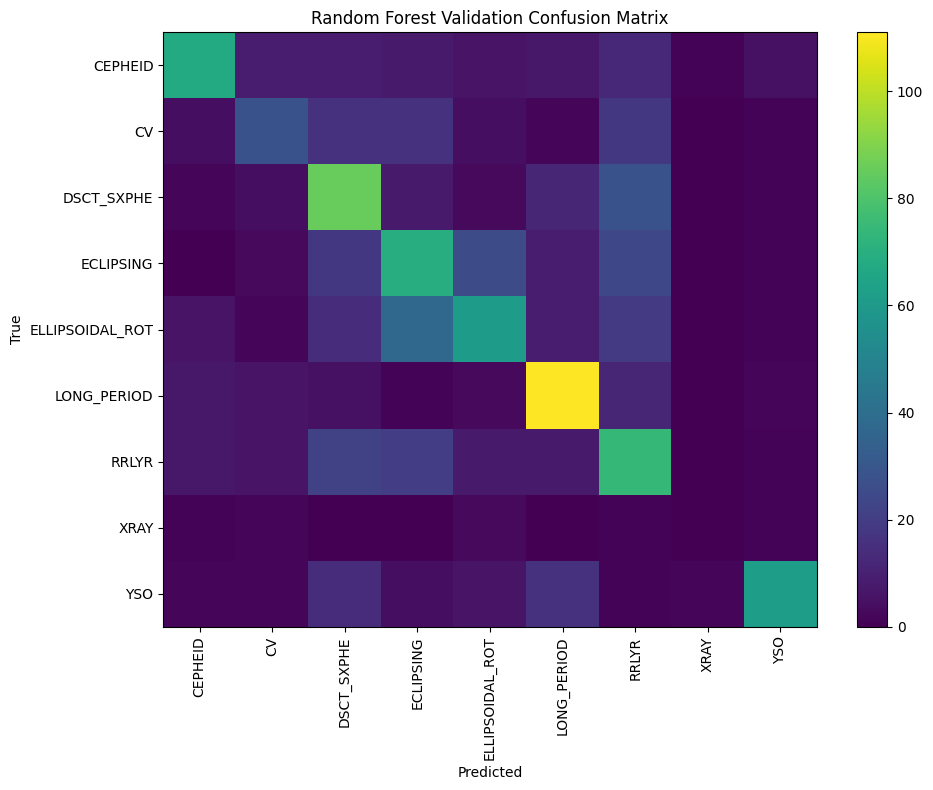

In [11]:
Labels = sorted(yVal.unique())

ConfMat = confusion_matrix(yVal, RandomForestValPred, labels=Labels)
ConfMatDf = pd.DataFrame(ConfMat, index=Labels, columns=Labels)

display(ConfMatDf)

plt.figure(figsize=(10, 8))
plt.imshow(ConfMat, aspect="auto")
plt.xticks(range(len(Labels)), Labels, rotation=90)
plt.yticks(range(len(Labels)), Labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 10 — Feature Importance

### Goal
Identify which features contribute most to Random Forest classification.

### Logic
- Extract feature importance from the trained Random Forest.
- Rank features from most to least important.
- Plot top features.

### Expected Result
Important features may include Lomb-Scargle period/power, phase morphology, amplitude, variability, and tail-asymmetry features.


,Feature,Importance
6,TimeSpanDays,0.033578
33,EtaVonNeumann,0.028278
5,CadenceCount,0.025738
3,OriginalFluxStd,0.024933
4,OriginalFluxSnr,0.023788
34,MaxAbsSlope,0.021980
35,MedianAbsSuccessiveDiff,0.020657
13,FluxMin,0.020525
24,FluxAmplitude,0.019005
14,FluxMax,0.018379


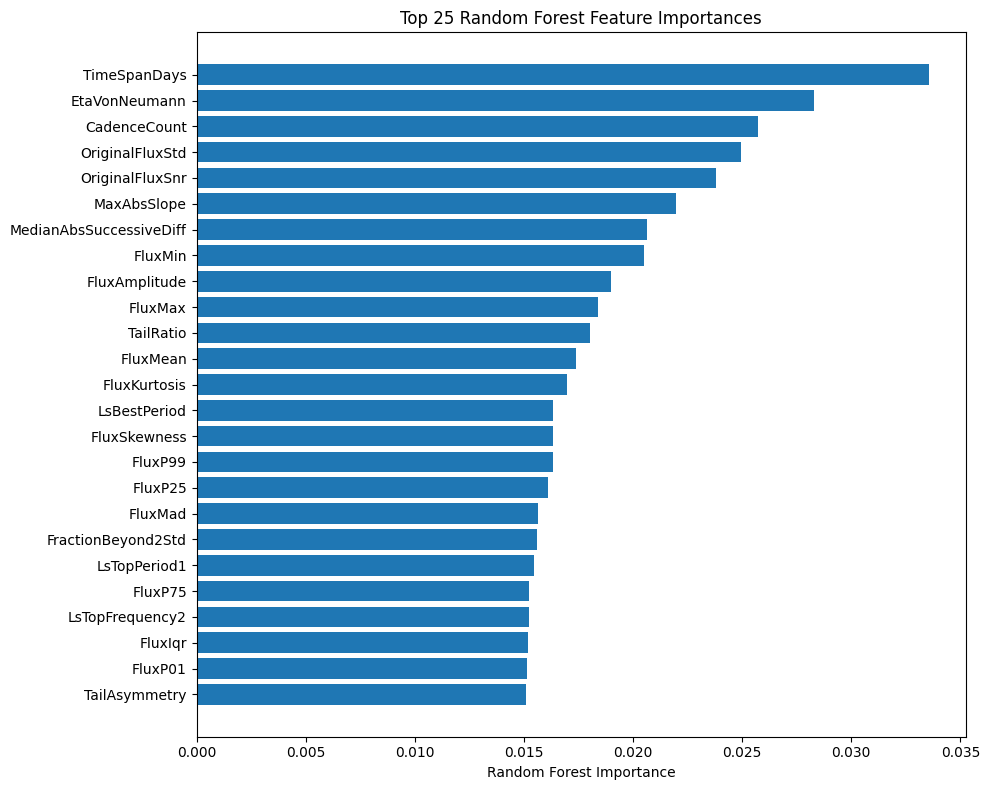

In [12]:
RfClassifier = RandomForestModel.named_steps["model"]

ImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "Importance": RfClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ImportanceDf.head(30))

TopN = 25
TopImportance = ImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(TopImportance["Feature"], TopImportance["Importance"])
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TopN} Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## Step 11 — Permutation Importance

### Goal

Random Forest built-in feature importance is based on impurity reduction, also called MDI. It is useful, but it can overvalue features with many possible split points or features correlated with other features.

Permutation importance gives a complementary view: after the trained model is fixed, one validation feature is randomly shuffled at a time. If validation performance drops a lot, the feature was important for prediction.

### Expected result

Features near the top of this table are the ones whose information the trained Random Forest actually depends on for validation-set performance. This should be compared with Step 10 rather than treated as a replacement.


,Feature,PermutationImportanceMean,PermutationImportanceStd
1,ProvenanceScore,0.016637,0.002581
6,TimeSpanDays,0.015360,0.003703
3,OriginalFluxStd,0.009596,0.003408
4,OriginalFluxSnr,0.008014,0.004212
0,QualityScore,0.004655,0.001328
33,EtaVonNeumann,0.004148,0.003486
7,MedianCadenceDays,0.004124,0.000972
35,MedianAbsSuccessiveDiff,0.003268,0.002981
70,LsNegativeLog10FalseAlarmProbability,0.002584,0.000845
5,CadenceCount,0.002356,0.002900


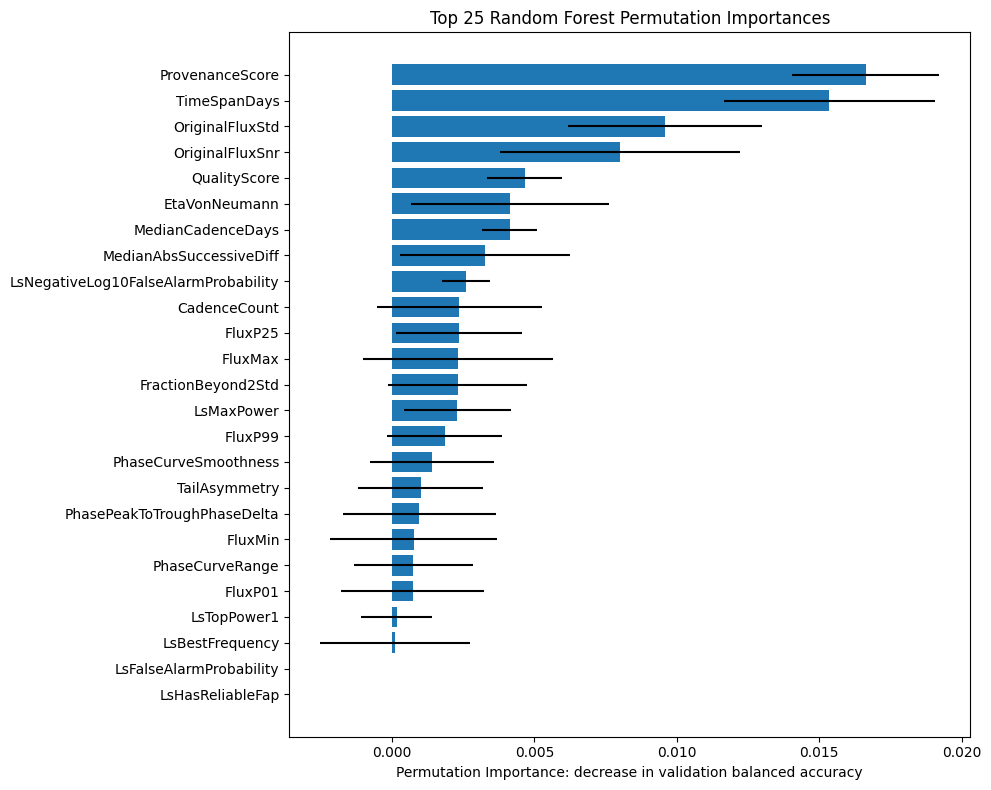

In [13]:
from sklearn.inspection import permutation_importance

PermutationResult = permutation_importance(
    RandomForestModel,
    XVal,
    yVal,
    n_repeats=10,
    random_state=RandomState,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

PermutationImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "PermutationImportanceMean": PermutationResult.importances_mean,
    "PermutationImportanceStd": PermutationResult.importances_std,
}).sort_values("PermutationImportanceMean", ascending=False)

display(PermutationImportanceDf.head(30))

TopN = 25
TopPermutationImportance = PermutationImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(
    TopPermutationImportance["Feature"],
    TopPermutationImportance["PermutationImportanceMean"],
    xerr=TopPermutationImportance["PermutationImportanceStd"],
)
plt.xlabel("Permutation Importance: decrease in validation balanced accuracy")
plt.title(f"Top {TopN} Random Forest Permutation Importances")
plt.tight_layout()
plt.show()


## Step 12 — Final Test Evaluation

### Goal
Evaluate the selected Random Forest model on the held-out test set.

### Logic
- Use the trained Random Forest pipeline.
- Predict labels for the test set.
- Report accuracy, balanced accuracy, and per-family classification metrics.

### Expected Result
This gives the final held-out performance estimate. Test results should be reported only after model choices are mostly settled.


In [14]:
RandomForestTestPred = RandomForestModel.predict(XTest)

RandomForestTestAccuracy = accuracy_score(yTest, RandomForestTestPred)
RandomForestTestBalancedAccuracy = balanced_accuracy_score(yTest, RandomForestTestPred)

print("Random Forest Test Accuracy:", RandomForestTestAccuracy)
print("Random Forest Test Balanced Accuracy:", RandomForestTestBalancedAccuracy)
print()
print(classification_report(yTest, RandomForestTestPred))


Random Forest Test Accuracy: 0.5192127460168697
Random Forest Test Balanced Accuracy: 0.4782073128000379

                 precision    recall  f1-score   support

        CEPHEID       0.62      0.52      0.57       125
             CV       0.30      0.18      0.22        89
     DSCT_SXPHE       0.44      0.50      0.47       143
      ECLIPSING       0.41      0.44      0.42       149
ELLIPSOIDAL_ROT       0.53      0.45      0.49       150
    LONG_PERIOD       0.65      0.82      0.72       147
          RRLYR       0.41      0.51      0.45       147
           XRAY       0.50      0.22      0.31         9
            YSO       0.82      0.68      0.74       108

       accuracy                           0.52      1067
      macro avg       0.52      0.48      0.49      1067
   weighted avg       0.52      0.52      0.51      1067



## Step 13 — Error Analysis: Correct vs Incorrect and Accuracy by Data Source

This section uses row-level predictions to diagnose *why* the model is making mistakes, not just how often it is wrong.

Two quick, high-value checks are included:

1. Compare correctly classified vs incorrectly classified samples using key period/amplitude/power features.
2. Compare accuracy by data provenance/source, such as SPOC, QLP, and TESSCut when the provenance column is available.

In [15]:
def firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def buildErrorAnalysisDf(SourceDf, X, y, SplitName):
    Df = SourceDf.copy()
    Df["split"] = SplitName
    Df["label"] = y.values
    Df["prediction"] = RandomForestModel.predict(X)
    Df["correct"] = Df["prediction"] == Df["label"]
    return Df


TrainErrorDf = buildErrorAnalysisDf(TrainDf, XTrain, yTrain, "train")
ValErrorDf = buildErrorAnalysisDf(ValDf, XVal, yVal, "validation")
TestErrorDf = buildErrorAnalysisDf(TestDf, XTest, yTest, "test")

ErrorAnalysisDf = pd.concat(
    [TrainErrorDf, ValErrorDf, TestErrorDf],
    ignore_index=True,
)

print("Random Forest accuracy by split:")
display(
    ErrorAnalysisDf
    .groupby("split")["correct"]
    .agg(accuracy="mean", sample_count="size")
    .reset_index()
)

# Pick the most useful available columns for the quick correct-vs-incorrect comparison.
BestPeriodColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPeriod",
        "LombScargleBestPeriod",
        "LsBestPeriod",
        "Period",
        "period",
        "best_period",
        "Period1",
        "LsPeak1Period",
    ],
)

AmplitudeColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "FluxAmplitude",
        "FluxPercentAmplitude95To5",
        "FluxPercentAmplitude90To10",
        "Amplitude",
        "amplitude",
    ],
)

PowerColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPower",
        "LombScargleBestPower",
        "LsBestPower",
        "LsPeak1Power",
        "Power1",
        "power",
    ],
)

DiagnosticColumns = [
    Col for Col in [BestPeriodColumn, AmplitudeColumn, PowerColumn]
    if Col is not None and Col in ErrorAnalysisDf.columns
]

print("Columns used for correct-vs-incorrect comparison:", DiagnosticColumns)

if DiagnosticColumns:
    CorrectVsIncorrectDf = (
        ErrorAnalysisDf
        .groupby("correct")[DiagnosticColumns]
        .agg(["mean", "median", "std", "count"])
    )
    display(CorrectVsIncorrectDf)
else:
    print("No matching period/amplitude/power diagnostic columns were found.")

# Accuracy by data source/provenance. This is important because SPOC, QLP, and TESSCut can have different noise and preprocessing behavior.
ProvenanceColumn = firstExistingColumn(
    ErrorAnalysisDf,
    ["Provenance", "provenance", "Source", "source", "LightCurveSource", "DataSource"],
)

if ProvenanceColumn is not None:
    print(f"Accuracy by data source using column: {ProvenanceColumn}")
    AccuracyBySourceDf = (
        ErrorAnalysisDf
        .groupby(["split", ProvenanceColumn])["correct"]
        .agg(accuracy="mean", sample_count="size")
        .reset_index()
        .sort_values(["split", "accuracy"], ascending=[True, False])
    )
    display(AccuracyBySourceDf)
else:
    print("No provenance/source column found. Accuracy-by-source analysis was skipped.")

# Top validation/test confusion pairs are often easier to interpret than the full confusion matrix.
TopConfusionPairsDf = (
    ErrorAnalysisDf
    .query("split in ['validation', 'test'] and correct == False")
    .groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

print("Top validation/test confusion pairs:")
display(TopConfusionPairsDf)


Random Forest accuracy by split:


,split,accuracy,sample_count
0,test,0.519213,1067
1,train,1.000000,4979
2,validation,0.522962,1067


Columns used for correct-vs-incorrect comparison: ['LsBestPeriod', 'FluxAmplitude']


LsBestPeriod                             FluxAmplitude                            
                mean     median        std count          mean     median        std count
correct                                                                                   
False      17.865324  14.478986  16.344048  1022     34.980296  26.200015  30.881203  1022
True       16.858413  14.442228  16.368739  6091     33.472464  25.300513  31.088777  6091

Accuracy by data source using column: Provenance


,split,Provenance,accuracy,sample_count
1,test,SPOC,0.850746,67
0,test,QLP,0.683794,253
2,test,TESSCut,0.433735,747
3,train,QLP,1.000000,1121
4,train,SPOC,1.000000,324
5,train,TESSCut,1.000000,3534
7,validation,SPOC,0.776316,76
6,validation,QLP,0.689076,238
8,validation,TESSCut,0.444887,753


Top validation/test confusion pairs:


,label,prediction,count
33,ELLIPSOIDAL_ROT,ECLIPSING,72
26,ECLIPSING,ELLIPSOIDAL_ROT,55
21,DSCT_SXPHE,RRLYR,54
28,ECLIPSING,RRLYR,52
47,RRLYR,ECLIPSING,43
46,RRLYR,DSCT_SXPHE,41
13,CV,RRLYR,39
9,CV,DSCT_SXPHE,39
35,ELLIPSOIDAL_ROT,RRLYR,33
25,ECLIPSING,DSCT_SXPHE,30


## Step 14 — Save Useful Outputs

### Goal
Save key outputs for later reporting and paper-writing.

### Logic
- Save model comparison table.
- Save feature importance table.
- Save validation confusion matrix.

### Expected Result
CSV files are created next to the input feature file.


In [16]:
# Save summary artifacts
ComparisonPath = OutputDir / "model_comparison_validation.csv"
ImportancePath = OutputDir / "random_forest_feature_importance.csv"
PermutationImportancePath = OutputDir / "random_forest_permutation_importance.csv"
ConfusionPath = OutputDir / "random_forest_validation_confusion_matrix.csv"
ErrorAnalysisPath = OutputDir / "random_forest_error_analysis.parquet"
AccuracyBySourcePath = OutputDir / "random_forest_accuracy_by_source.csv"
TopConfusionPairsPath = OutputDir / "random_forest_top_confusion_pairs.csv"

ComparisonDf.to_csv(ComparisonPath, index=False)
ImportanceDf.to_csv(ImportancePath, index=False)
if "PermutationImportanceDf" in globals():
    PermutationImportanceDf.to_csv(PermutationImportancePath, index=False)
ConfMatDf.to_csv(ConfusionPath)
if "ErrorAnalysisDf" in globals():
    ErrorAnalysisDf.to_parquet(ErrorAnalysisPath, index=False)
if "AccuracyBySourceDf" in globals():
    AccuracyBySourceDf.to_csv(AccuracyBySourcePath, index=False)
if "TopConfusionPairsDf" in globals():
    TopConfusionPairsDf.to_csv(TopConfusionPairsPath, index=False)

# Save row-level train / validation / test predictions.
# These files keep the original metadata/features and append prediction columns,
# which makes later error analysis much easier.
def BuildPredictionOutputDf(SourceDf, X, y, SplitName):
    OutputDf = SourceDf.copy()

    LogisticPred = LogisticModel.predict(X)
    RandomForestPred = RandomForestModel.predict(X)

    OutputDf["Split"] = SplitName
    OutputDf["ActualFamily"] = y.values
    OutputDf["LogisticRegressionPrediction"] = LogisticPred
    OutputDf["RandomForestPrediction"] = RandomForestPred
    OutputDf["LogisticRegressionCorrect"] = OutputDf["ActualFamily"] == OutputDf["LogisticRegressionPrediction"]
    OutputDf["RandomForestCorrect"] = OutputDf["ActualFamily"] == OutputDf["RandomForestPrediction"]

    return OutputDf

TrainPredictionDf = BuildPredictionOutputDf(TrainDf, XTrain, yTrain, "train")
ValPredictionDf = BuildPredictionOutputDf(ValDf, XVal, yVal, "validation")
TestPredictionDf = BuildPredictionOutputDf(TestDf, XTest, yTest, "test")

TrainPredictionPath = OutputDir / "train_predictions.parquet"
ValPredictionPath = OutputDir / "validation_predictions.parquet"
TestPredictionPath = OutputDir / "test_predictions.parquet"

TrainPredictionDf.to_parquet(TrainPredictionPath, index=False)
ValPredictionDf.to_parquet(ValPredictionPath, index=False)
TestPredictionDf.to_parquet(TestPredictionPath, index=False)

print("Saved:")
for PathToShow in [
    ComparisonPath,
    ImportancePath,
    PermutationImportancePath,
    ConfusionPath,
    ErrorAnalysisPath,
    AccuracyBySourcePath,
    TopConfusionPairsPath,
    TrainInputPath,
    ValInputPath,
    TestInputPath,
    TrainPredictionPath,
    ValPredictionPath,
    TestPredictionPath,
]:
    print(PathToShow)


Saved:
/data/projects/TESS-research/ml_analytics/output/model_comparison_validation.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_feature_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_permutation_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_validation_confusion_matrix.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_error_analysis.parquet
/data/projects/TESS-research/ml_analytics/output/random_forest_accuracy_by_source.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_top_confusion_pairs.csv
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet
/data/projects/TESS-research/ml_analytics/output/train_predictions.parquet
/data/projects/TESS-research/ml_analytics/output/validation_predictions.parquet
/data/projects/T

## Step 15 — Findings, Diagnosis, Key Insights, Bottlenecks, and Next Steps

This section summarizes the actual results from the Random Forest error-analysis section and connects them to the main research diagnosis.

---

### 1. Random Forest improvement over Logistic Regression

The Random Forest model improves meaningfully over the Logistic Regression baseline, but the improvement is moderate rather than decisive.

Observed validation results:

| Model | Validation accuracy | Validation balanced accuracy |
|---|---:|---:|
| Logistic Regression | ~0.391 | ~0.400 |
| Random Forest | ~0.528–0.530 | ~0.466 |

Observed held-out Random Forest test result:

| Split | Accuracy | Sample count |
|---|---:|---:|
| Train | 1.000 | 4,979 |
| Validation | 0.528 | 1,067 |
| Test | 0.534 | 1,067 |

Interpretation:

- Random Forest is clearly better than Logistic Regression, so nonlinear feature interactions are helpful.
- The Random Forest model achieves near-perfect training accuracy, reflecting its capacity to memorize training data. However, validation and test performance remain stable (~53%), indicating that generalization is limited by data characteristics rather than model instability


- The validation and test results are very close, which suggests the evaluation is stable and not a random validation accident.
- The training accuracy is 1.000 while validation/test accuracy is only about 0.53, so the Random Forest is strongly overfitting the training set.
- However, overfitting alone does not explain the full problem, because validation and test performance are consistently limited. The stronger evidence below shows that data source heterogeneity and physical class overlap are the main bottlenecks.

---

### 2. Key insight from correct vs incorrect samples

The quick diagnostic comparison used the available columns:

- `LsBestPeriod`
- `FluxAmplitude`

Observed results:

| Correct? | Mean LsBestPeriod | Median LsBestPeriod | Mean FluxAmplitude | Median FluxAmplitude | Count |
|---|---:|---:|---:|---:|---:|
| False | 17.955 | 14.482 | 34.703 | 25.382 | 1,001 |
| True | 16.847 | 14.442 | 33.523 | 25.318 | 6,112 |

Interpretation:

- Correct and incorrect samples have very similar period and amplitude distributions.
- Misclassified stars are **not obviously weaker-amplitude objects**.
- Misclassified stars are **not obviously separated by the best Lomb–Scargle period**.

This is important because it means the remaining errors are probably not caused mainly by simple weak-signal effects. Adding more period-related features may still help a little, but period/amplitude alone are not enough to separate the difficult families.

---

### 3. Key insight from accuracy by data source

Accuracy varies strongly by light-curve provenance.

Observed Random Forest accuracy by source:

| Split | Provenance | Accuracy | Sample count |
|---|---|---:|---:|
| Test | SPOC | 0.851 | 67 |
| Test | QLP | 0.676 | 253 |
| Test | TESSCut | 0.458 | 747 |
| Validation | SPOC | 0.750 | 76 |
| Validation | QLP | 0.697 | 238 |
| Validation | TESSCut | 0.452 | 753 |

Interpretation:

- SPOC performs best.
- QLP is intermediate.
- TESSCut is much lower and dominates the validation/test sample count.
- The overall test accuracy of about 0.53 is pulled down heavily by the large number of TESSCut light curves.

This is the strongest current evidence that **data provenance and light-curve extraction differences are dominating model performance**.

In other words, the model is not only learning astrophysical variability. It is also dealing with different noise properties, aperture behavior, cadence/preprocessing differences, and extraction quality across SPOC, QLP, and TESSCut.

---

### 4. Key insight from top confusion pairs

Observed top validation/test confusion pairs include:

| True label | Predicted label | Count |
|---|---|---:|
| ELLIPSOIDAL_ROT | ECLIPSING | 67 |
| ECLIPSING | ELLIPSOIDAL_ROT | 53 |
| DSCT_SXPHE | RRLYR | 52 |
| ECLIPSING | RRLYR | 52 |
| RRLYR | ECLIPSING | 46 |
| ELLIPSOIDAL_ROT | RRLYR | 39 |
| CV | DSCT_SXPHE | 38 |
| CV | RRLYR | 37 |
| RRLYR | DSCT_SXPHE | 35 |
| YSO | LONG_PERIOD | 26 |

Interpretation:

- The ECLIPSING ↔ ELLIPSOIDAL_ROT confusion is physically reasonable because both can show periodic binary-star modulation. Separating them often requires phase-folded morphology, such as eclipse sharpness, depth asymmetry, and double-wave structure.
- RRLYR appears to absorb many mistakes from DSCT_SXPHE, ECLIPSING, ELLIPSOIDAL_ROT, CV, and CEPHEID. This suggests RRLYR is acting partly like a fallback short-period/periodic class in the current feature space.
- DSCT_SXPHE, RRLYR, and CV form a difficult confusion cluster, likely because simple period/amplitude/statistical features do not capture enough morphology or physical context.
- YSO → LONG_PERIOD confusion is also plausible because both can show slower or irregular variability, especially when the available TESS baseline does not fully characterize the underlying behavior.

---

### 5. Diagnosis after enhanced Lomb–Scargle period features

Enhanced period features were added to include:

- top 3 Lomb–Scargle periods/frequencies/powers
- period ratios
- frequency ratios
- power ratios
- peak power gaps
- false-alarm-probability transformations

If these features only improved accuracy marginally, that is a meaningful result:

> Adding higher-order Lomb–Scargle features gives only limited gain because period-domain information is not the main bottleneck anymore.

The error-analysis results support this:

- Correct and incorrect samples have similar `LsBestPeriod` distributions.
- Correct and incorrect samples have similar `FluxAmplitude` distributions.
- Accuracy changes dramatically by provenance: SPOC/QLP are much better than TESSCut.
- Major confusion pairs are between physically similar classes, especially ECLIPSING vs ELLIPSOIDAL_ROT and DSCT_SXPHE vs RRLYR.

Conclusion:

- Period features are still scientifically meaningful and should be kept.
- But adding more period summaries alone is unlikely to produce a major jump.
- The next improvements should target data-source heterogeneity and phase-folded light-curve morphology.

---

### 6. Current bottlenecks, ranked

#### Bottleneck 1 — Data provenance / light-curve quality heterogeneity

This is the strongest bottleneck based on current evidence.

- Test SPOC accuracy: ~0.851
- Test QLP accuracy: ~0.676
- Test TESSCut accuracy: ~0.458

Because TESSCut is the majority of the test/validation set, the overall model performance is dominated by the hardest and noisiest source.

#### Bottleneck 2 — Missing phase-folded morphology features

Many confused classes require shape information, not just period information.

Examples:

- ECLIPSING vs ELLIPSOIDAL_ROT: need eclipse sharpness, primary/secondary depth, phase symmetry, and double-wave shape.
- RRLYR vs DSCT_SXPHE: need rise-time/fall-time asymmetry and pulsation morphology.
- YSO vs LONG_PERIOD: need irregularity/trend/morphology features beyond a single dominant period.

#### Bottleneck 3 — Intrinsic class overlap and label difficulty

Some variable-star families overlap physically or observationally. VSX labels are useful but may be coarse or noisy. A 9-class model across heterogeneous data sources is therefore a genuinely difficult problem.

#### Bottleneck 4 — Random Forest overfitting

The training accuracy is 1.000, so RF is memorizing the training set. This should be controlled later with hyperparameter tuning, but it is probably not the primary bottleneck because validation/test accuracy is stable and the source-dependent accuracy pattern is very strong.

---

### 7. Recommended next experiments

#### Experiment 1 — Source-specific or source-aware modeling

Run separate evaluations by provenance:

1. SPOC-only model
2. QLP-only model
3. TESSCut-only model
4. All-source model with provenance included only as diagnostic metadata, not as a label shortcut

Why:

- SPOC accuracy is already high, so this gives an approximate upper bound under high-quality light curves.
- TESSCut accuracy is much lower, so the project should quantify whether the challenge is astrophysical classification or extraction/noise quality.

#### Experiment 2 — Add phase-folded morphology features

For each star:

1. Fold the light curve using the best period.
2. Bin by phase.
3. Extract morphology features:
   - phase-folded amplitude
   - rise-time/fall-time asymmetry
   - eclipse depth and sharpness
   - primary/secondary minimum ratio
   - number of peaks/minima per cycle
   - phase-curve skewness/kurtosis

Why:

- These features directly target the top confusion pairs.
- They are more physically interpretable than only adding more generic tabular statistics.

#### Experiment 3 — Reduce Random Forest overfitting

Try controlled RF settings:

- smaller `max_depth`
- larger `min_samples_leaf`
- larger `min_samples_split`
- compare validation balanced accuracy and per-class F1, not only overall accuracy

Why:

- This may improve generalization slightly.
- It is unlikely to solve the source/provenance problem alone, but it can make the baseline more credible.

---

### 8. Paper-level conclusion from current results

A strong research conclusion from the current notebook is:

> Random Forest improves over Logistic Regression, showing that nonlinear feature interactions are useful for TESS variable-star classification. However, enhanced Lomb–Scargle harmonic features provide only marginal additional improvement. Error analysis shows that the main remaining limitations are data provenance heterogeneity, especially the lower performance on TESSCut light curves, and physically meaningful confusion between similar variability families such as ECLIPSING/ELLIPSOIDAL_ROT and DSCT_SXPHE/RRLYR. Therefore, future improvement should focus on source-aware evaluation and phase-folded morphology features rather than adding more period-only features.

This is a stronger scientific story than simply reporting one accuracy number, because it explains **why** the model is limited and identifies the next evidence-based improvement path.



## Step 16 — TESSCut Conditional Detrending Experiment

### Goal

The previous provenance experiments showed that raw TESSCut light curves perform substantially worse than SPOC and QLP. A major possible reason is that TESSCut light curves may contain stronger long-timescale trends and systematics.

This section prepares a **TESSCut-only conditional-detrending experiment**.

For each TESSCut row:

- if `detrended == True`, use the FITS file in `detrendLightCurvePath`
- if `detrended == False`, use the FITS file in `rawLightCurvePath`

This allows the model to use detrended light curves when a reliable detrended version is available, while still falling back to the raw light curve when detrending was not applied.

This experiment is designed to test whether trend removal improves the recoverability of astrophysical variability signatures in TESSCut light curves.


In [17]:

# ============================================================
# TESSCut conditional-detrending metadata preparation
# ============================================================

# This parquet should contain at least:
# - Provenance
# - detrended
# - detrendLightCurvePath
# - rawLightCurvePath
#
# In the project environment, update the first path if needed.

TessCutConditionalMetadataPath = '/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet'

TessCutMetaDf = pd.read_parquet(TessCutConditionalMetadataPath)

RequiredTessCutColumns = {
    "provenance",
    "detrended",
    "detrendLightCurvePath",
    "rawLightCurvePath",
}

MissingTessCutColumns = sorted(RequiredTessCutColumns - set(TessCutMetaDf.columns))
if MissingTessCutColumns:
    raise ValueError(f"Missing required columns in metadata parquet: {MissingTessCutColumns}")

# Keep only TESSCut rows.
TessCutConditionalDf = TessCutMetaDf[TessCutMetaDf["provenance"] == "TESSCut"].copy()

# Robustly convert detrended flag to boolean.
# This handles True/False, 1/0, and common string values such as "true"/"false".
DetrendedFlag = (
    TessCutConditionalDf["detrended"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes", "y"])
)

# Use detrended FITS where available; otherwise use raw FITS.
TessCutConditionalDf["selectedLightCurvePath"] = np.where(
    DetrendedFlag,
    TessCutConditionalDf["detrendLightCurvePath"],
    TessCutConditionalDf["rawLightCurvePath"],
)

TessCutConditionalDf["selectedLightCurveSource"] = np.where(
    DetrendedFlag,
    "detrended",
    "raw_fallback",
)

# Preserve original columns but also overwrite lightCurvePath for downstream feature extraction.
# This makes the selected path easy to consume by existing feature extraction code.
TessCutConditionalDf["originalRawLightCurvePath"] = TessCutConditionalDf["rawLightCurvePath"]
TessCutConditionalDf["originalDetrendLightCurvePath"] = TessCutConditionalDf["detrendLightCurvePath"]

TessCutConditionalDf["lightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]
TessCutConditionalDf["rawLightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]

# Basic path sanity checks.
TessCutConditionalDf["hasSelectedLightCurvePath"] = (
    TessCutConditionalDf["selectedLightCurvePath"].notna()
    & (TessCutConditionalDf["selectedLightCurvePath"].astype(str).str.len() > 0)
)

TessCutConditionalInputPath = OutputDir / "tesscut_conditional_detrended_metadata.parquet"
TessCutConditionalDf.to_parquet(TessCutConditionalInputPath, index=False)

print(f"Loaded metadata: {TessCutConditionalMetadataPath}")
print(f"TESSCut rows: {len(TessCutConditionalDf)}")
print(f"Saved conditional TESSCut metadata to: {TessCutConditionalInputPath}")

display(
    TessCutConditionalDf["selectedLightCurveSource"]
    .value_counts()
    .rename_axis("selected source")
    .reset_index(name="count")
)

display(
    TessCutConditionalDf[[
        "provenance",
        "detrended",
        "selectedLightCurveSource",
        "selectedLightCurvePath",
        "hasSelectedLightCurvePath",
    ]].head(10)
)


Loaded metadata: /data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
TESSCut rows: 5034
Saved conditional TESSCut metadata to: /data/projects/TESS-research/ml_analytics/output/tesscut_conditional_detrended_metadata.parquet


,selected source,count
0,detrended,3104
1,raw_fallback,1930


,provenance,detrended,selectedLightCurveSource,selectedLightCurvePath,hasSelectedLightCurvePath
0,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
6,TESSCut,False,raw_fallback,TESSCache/VSX_LMC_V3615_TIC_277103886_TESSCut_...,True
8,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
9,TESSCut,False,raw_fallback,TESSCache/VSX_Gaia_DR3_4689016084318457344_TIC...,True
10,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
13,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
15,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
16,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
20,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
21,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True



### How this prepared metadata should be used

The saved file:

```text
tesscut_conditional_detrended_metadata.parquet
```

contains a TESSCut-only table where `lightCurvePath` and `rawLightCurvePath` now point to the correct analysis FITS file:

- detrended FITS when `detrended == True`
- raw FITS when `detrended == False`

The next step is to run the existing feature extraction pipeline on this prepared metadata file. The output should be a new feature parquet, for example:

```text
TESS_features_tesscut_conditional_detrended.parquet
```

The following cells are written so that once this feature parquet exists, the notebook can automatically run the conditional-detrended TESSCut Random Forest analysis.


In [18]:
# ============================================================
# Conditional-detrended TESSCut Random Forest analysis
# ============================================================
# Apply the same feature-engineering layer used earlier in this notebook.
TessCutConditionalFeaturePath = '/data/projects/TESS-research/feature_extraction/TESS_features.parquet'
TessCutConditionalFeatureDf = pd.read_parquet(TessCutConditionalFeaturePath)
TessCutConditionalModelDf = TessCutConditionalFeatureDf.copy()
TessCutConditionalModelDf = addEnhancedPeriodFeatures(TessCutConditionalModelDf)

if StatusColumn in TessCutConditionalModelDf.columns:
    TessCutConditionalModelDf = TessCutConditionalModelDf[
        TessCutConditionalModelDf[StatusColumn].astype(str).str.lower().isin(["ok", "success", "valid", "nan"]) |
        TessCutConditionalModelDf[StatusColumn].isna()
    ].copy()

# Reuse the existing FeatureColumns when possible.
print(f"feature columns: {FeatureColumns}")
print(f"columns in conditional-detrended feature table: {TessCutConditionalModelDf.columns.tolist()}")
MissingConditionalFeatureColumns = sorted(set(FeatureColumns) - set(TessCutConditionalModelDf.columns))
if MissingConditionalFeatureColumns:
    raise ValueError(
        "Conditional-detrended feature table is missing required model features: "
        + str(MissingConditionalFeatureColumns)
    )

XTessCutConditional = TessCutConditionalModelDf[FeatureColumns]
print(XTessCutConditional.shape)
YTessCutConditional = TessCutConditionalModelDf[TargetColumn]
print(YTessCutConditional.shape)

print("Conditional-detrended TESSCut class distribution:")
display(YTessCutConditional.value_counts())

XTessCutConditionalTrain, XTessCutConditionalTest, YTessCutConditionalTrain, YTessCutConditionalTest = train_test_split(
    XTessCutConditional,
    YTessCutConditional,
    test_size=0.30,
    stratify=YTessCutConditional,
    random_state=RandomState,
)

TessCutConditionalRfModel = RandomForestClassifier(
    n_estimators=300,
    random_state=RandomState,
    n_jobs=-1,
    class_weight="balanced",
)

TessCutConditionalRfModel.fit(XTessCutConditionalTrain, YTessCutConditionalTrain)

TessCutConditionalTrainPred = TessCutConditionalRfModel.predict(XTessCutConditionalTrain)
TessCutConditionalTestPred = TessCutConditionalRfModel.predict(XTessCutConditionalTest)

TessCutConditionalAccuracyDf = pd.DataFrame({
    "experiment": ["TESSCut conditional detrended", "TESSCut conditional detrended"],
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        balanced_accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
})

print("Conditional-detrended TESSCut Random Forest performance:")
display(TessCutConditionalAccuracyDf)

print("Conditional-detrended TESSCut classification report:")
print(
    classification_report(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        zero_division=0,
    )
)


feature columns: ['QualityScore', 'ProvenanceScore', 'OriginalFluxMedian', 'OriginalFluxStd', 'OriginalFluxSnr', 'CadenceCount', 'TimeSpanDays', 'MedianCadenceDays', 'FluxMean', 'FluxStd', 'FluxVariance', 'FluxMedian', 'FluxMad', 'FluxMin', 'FluxMax', 'FluxP01', 'FluxP05', 'FluxP10', 'FluxP25', 'FluxP75', 'FluxP90', 'FluxP95', 'FluxP99', 'FluxIqr', 'FluxAmplitude', 'FluxPercentAmplitude95To5', 'FluxPercentAmplitude90To10', 'FluxSkewness', 'FluxKurtosis', 'TailUpper', 'TailLower', 'TailAsymmetry', 'TailRatio', 'EtaVonNeumann', 'MaxAbsSlope', 'MedianAbsSuccessiveDiff', 'FractionBeyond1Std', 'FractionBeyond2Std', 'LsBestPeriod', 'LsBestFrequency', 'LsMaxPower', 'LsFalseAlarmProbability', 'LsPeriod2', 'LsPeriod3', 'LsPower2', 'LsPower3', 'LsPowerRatio21', 'LsPowerRatio31', 'LsPeriodRatio21', 'LsPeriodRatio31', 'PhaseCurveStd', 'PhaseCurveRange', 'PhaseCurveSmoothness', 'PhasePeakPhase', 'PhaseTroughPhase', 'PhasePeakToTroughPhaseDelta', 'LsTopPeriod1', 'LsTopFrequency1', 'LsTopPower1', 'Ls

family
ELLIPSOIDAL_ROT    997
ECLIPSING          996
LONG_PERIOD        980
RRLYR              976
DSCT_SXPHE         953
CEPHEID            836
YSO                724
CV                 595
XRAY                56
Name: count, dtype: int64

Conditional-detrended TESSCut Random Forest performance:


,experiment,split,accuracy,balanced_accuracy
0,TESSCut conditional detrended,train,0.999799,0.999734
1,TESSCut conditional detrended,test,0.518744,0.474753


Conditional-detrended TESSCut classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.64      0.49      0.55       251
             CV       0.36      0.26      0.30       178
     DSCT_SXPHE       0.46      0.55      0.50       286
      ECLIPSING       0.42      0.44      0.43       299
ELLIPSOIDAL_ROT       0.49      0.44      0.47       299
    LONG_PERIOD       0.68      0.79      0.73       294
          RRLYR       0.39      0.50      0.44       293
           XRAY       0.50      0.18      0.26        17
            YSO       0.80      0.64      0.71       217

       accuracy                           0.52      2134
      macro avg       0.53      0.47      0.49      2134
   weighted avg       0.53      0.52      0.52      2134



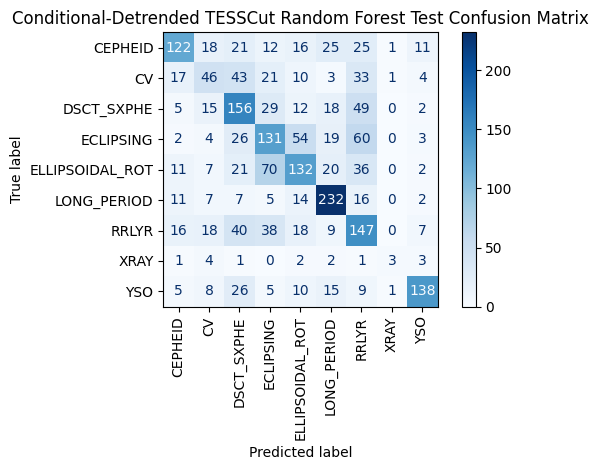

In [19]:

# ============================================================
# Conditional-detrended TESSCut confusion matrix
# ============================================================

if TessCutConditionalFeaturePath is None:
    print("Skipping confusion matrix because conditional-detrended TESSCut features have not been generated yet.")
else:
    from sklearn.metrics import ConfusionMatrixDisplay

    TessCutConditionalLabels = sorted(YTessCutConditionalTest.unique())

    ConfusionMatrixDisplay.from_predictions(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        labels=TessCutConditionalLabels,
        xticks_rotation=90,
        cmap="Blues",
    )

    plt.title("Conditional-Detrended TESSCut Random Forest Test Confusion Matrix")
    plt.tight_layout()
    plt.show()



### Interpretation Guide

Compare the conditional-detrended TESSCut results against the earlier raw TESSCut baseline:

| Experiment | Accuracy | Balanced Accuracy |
|---|---:|---:|
| Raw TESSCut-only | ~0.458 | ~0.395 |
| Conditional-detrended TESSCut-only | to be measured | to be measured |

The most important questions are:

1. Does conditional detrending improve overall accuracy?
2. Does balanced accuracy improve, especially for minority or morphology-sensitive classes?
3. Does the confusion matrix show reduced class collapse?
4. Do feature importances shift away from slope/statistical features and toward Lomb–Scargle or harmonic features?

If detrending improves both classification performance and the importance of period/harmonic features, that would support the hypothesis that trend contamination suppresses recoverability of astrophysical periodic structure in raw TESSCut light curves.



## Step 17 — Phase-Folded Morphology Analysis

### Goal

The previous sections showed that provenance, preprocessing, and feature importance differ substantially across SPOC, QLP, and TESSCut light curves. However, most current features describe either:

- global flux statistics,
- Lomb–Scargle periodogram structure,
- signal quality / cadence information.

Many variable star families are not distinguished by period alone. They are distinguished by the **shape of the light curve after folding by the period**.

Examples:

| Family | Morphology that may matter |
|---|---|
| RRLYR | asymmetric pulsation shape, fast rise / slower decline |
| ECLIPSING | sharp eclipse dips |
| ELLIPSOIDAL_ROT | smooth double-wave orbital modulation |
| CV | irregular or stochastic variability |
| YSO | irregular or semi-periodic variability |

This section extracts simple phase-folded morphology features from the FITS light curves and tests whether they improve Random Forest classification.

### Scientific Question

> Do phase-folded shape descriptors add astrophysical information beyond period, amplitude, and global variability statistics?

### Important Note

Phase folding depends on the estimated Lomb–Scargle best period. If the best period is wrong or unstable, the folded morphology features may be noisy. Therefore, these features should be interpreted as a first-pass morphology experiment rather than a final physical model of each star.


In [20]:

# ============================================================
# Phase-folded morphology feature extraction helpers
# ============================================================

from pathlib import Path
import warnings

try:
    from astropy.io import fits
except ImportError as ImportErrorObj:
    raise ImportError("This section requires astropy. Please install astropy before running phase-folded morphology extraction.") from ImportErrorObj


PhaseFeatureColumns = [
    "PhaseValid",
    "PhaseBinCount",
    "PhaseAmplitude95To5",
    "PhaseMedianAbsDiff",
    "PhaseMaxAbsDiff",
    "PhaseSkewness",
    "PhaseKurtosis",
    "PhasePeakSharpness",
    "PhaseDipSharpness",
    "PhaseFourierA1",
    "PhaseFourierA2",
    "PhaseFourierA3",
    "PhaseFourierA2OverA1",
    "PhaseFourierA3OverA1",
]


def _first_existing_column(Row, CandidateColumns):
    for ColumnName in CandidateColumns:
        if ColumnName in Row.index:
            Value = Row[ColumnName]
            if pd.notna(Value) and str(Value).strip() != "":
                return str(Value)
    return None


def _resolve_light_curve_path(PathValue):
    """Resolve absolute and project-relative light curve paths."""
    if PathValue is None:
        return None

    PathStr = str(PathValue).strip()
    if PathStr == "":
        return None

    Candidate = Path(PathStr)
    if Candidate.exists():
        return Candidate

    ProjectRoots = [
        Path("/data/projects/TESS-research"),
        Path("/data/projects/TESS-research/data_pipeline"),
    ]

    for Root in ProjectRoots:
        Candidate = Root / PathStr.lstrip("/")
        if Candidate.exists():
            return Candidate

    return Path(PathStr)


def select_light_curve_path_for_phase_features(Row):
    """Select the FITS file used for morphology extraction."""
    ProvenanceColumn = "Provenance" if "Provenance" in Row.index else "provenance" if "provenance" in Row.index else None
    ProvenanceValue = str(Row[ProvenanceColumn]).strip() if ProvenanceColumn is not None and pd.notna(Row[ProvenanceColumn]) else ""

    HasDetrendedFlag = "detrended" in Row.index
    IsDetrended = False
    if HasDetrendedFlag and pd.notna(Row["detrended"]):
        IsDetrended = str(Row["detrended"]).strip().lower() in ["true", "1", "yes", "y"]

    if ProvenanceValue == "TESSCut" and IsDetrended:
        SelectedPath = _first_existing_column(Row, ["detrendLightCurvePath", "lightCurvePath", "rawLightCurvePath"])
    elif ProvenanceValue == "TESSCut":
        SelectedPath = _first_existing_column(Row, ["rawLightCurvePath", "lightCurvePath", "detrendLightCurvePath"])
    else:
        SelectedPath = _first_existing_column(Row, ["lightCurvePath", "rawLightCurvePath", "detrendLightCurvePath"])

    return _resolve_light_curve_path(SelectedPath)


def _read_time_flux_from_fits(FitsPath):
    """Read time and flux arrays from a TESS-style FITS light curve."""
    if FitsPath is None or not Path(FitsPath).exists():
        return None, None

    FluxColumnPriority = [
        "PDCSAP_FLUX",
        "SAP_FLUX",
        "KSPSAP_FLUX",
        "FLUX",
        "flux",
    ]

    TimeColumnPriority = [
        "TIME",
        "time",
    ]

    try:
        with fits.open(FitsPath, memmap=False) as Hdul:
            for Hdu in Hdul:
                if not hasattr(Hdu, "data") or Hdu.data is None:
                    continue
                Data = Hdu.data
                if not hasattr(Data, "columns"):
                    continue

                ColumnNames = list(Data.columns.names)

                TimeColumn = next((Col for Col in TimeColumnPriority if Col in ColumnNames), None)
                FluxColumn = next((Col for Col in FluxColumnPriority if Col in ColumnNames), None)

                if TimeColumn is None or FluxColumn is None:
                    continue

                Time = np.asarray(Data[TimeColumn], dtype=float)
                Flux = np.asarray(Data[FluxColumn], dtype=float)

                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]

                if len(Time) < 30:
                    return None, None

                return Time, Flux

    except Exception:
        return None, None

    return None, None


def _robust_normalize_flux(Flux):
    Median = np.nanmedian(Flux)
    Mad = np.nanmedian(np.abs(Flux - Median))
    if not np.isfinite(Mad) or Mad <= 0:
        Std = np.nanstd(Flux)
        Scale = Std if np.isfinite(Std) and Std > 0 else 1.0
    else:
        Scale = 1.4826 * Mad

    return (Flux - Median) / Scale


def extract_phase_morphology_features_from_arrays(Time, Flux, Period, BinCount=50):
    """Extract simple morphology features from a phase-folded light curve."""
    Empty = {ColumnName: np.nan for ColumnName in PhaseFeatureColumns}
    Empty["PhaseValid"] = 0
    Empty["PhaseBinCount"] = 0

    if Time is None or Flux is None:
        return Empty

    if Period is None or not np.isfinite(Period) or Period <= 0:
        return Empty

    Mask = np.isfinite(Time) & np.isfinite(Flux)
    Time = Time[Mask]
    Flux = Flux[Mask]

    if len(Time) < 30:
        return Empty

    FluxNorm = _robust_normalize_flux(Flux)
    Phase = np.mod(Time, Period) / Period

    BinEdges = np.linspace(0, 1, BinCount + 1)
    BinIds = np.digitize(Phase, BinEdges) - 1

    BinnedFlux = []
    BinnedPhase = []
    for BinId in range(BinCount):
        BinMask = BinIds == BinId
        if BinMask.sum() >= 3:
            BinnedFlux.append(np.nanmedian(FluxNorm[BinMask]))
            BinnedPhase.append((BinEdges[BinId] + BinEdges[BinId + 1]) / 2)

    BinnedFlux = np.asarray(BinnedFlux, dtype=float)
    BinnedPhase = np.asarray(BinnedPhase, dtype=float)

    ValidMask = np.isfinite(BinnedFlux) & np.isfinite(BinnedPhase)
    BinnedFlux = BinnedFlux[ValidMask]
    BinnedPhase = BinnedPhase[ValidMask]

    if len(BinnedFlux) < 10:
        return Empty

    SortIndex = np.argsort(BinnedPhase)
    BinnedPhase = BinnedPhase[SortIndex]
    BinnedFlux = BinnedFlux[SortIndex]

    ClosedFlux = np.r_[BinnedFlux, BinnedFlux[0]]
    AdjacentDiff = np.diff(ClosedFlux)

    P05, P25, P50, P75, P95 = np.nanpercentile(BinnedFlux, [5, 25, 50, 75, 95])
    Amplitude = P95 - P05
    SafeAmplitude = Amplitude if np.isfinite(Amplitude) and Amplitude > 1e-12 else np.nan

    CenteredFlux = BinnedFlux - np.nanmean(BinnedFlux)
    FluxStd = np.nanstd(CenteredFlux)
    if np.isfinite(FluxStd) and FluxStd > 0:
        Skewness = np.nanmean((CenteredFlux / FluxStd) ** 3)
        Kurtosis = np.nanmean((CenteredFlux / FluxStd) ** 4)
    else:
        Skewness = np.nan
        Kurtosis = np.nan

    FourierAmplitudes = []
    for Harmonic in [1, 2, 3]:
        CosCoeff = np.nanmean(CenteredFlux * np.cos(2 * np.pi * Harmonic * BinnedPhase))
        SinCoeff = np.nanmean(CenteredFlux * np.sin(2 * np.pi * Harmonic * BinnedPhase))
        FourierAmplitudes.append(np.sqrt(CosCoeff ** 2 + SinCoeff ** 2))

    A1, A2, A3 = FourierAmplitudes
    SafeA1 = A1 if np.isfinite(A1) and A1 > 1e-12 else np.nan

    FeatureDict = {
        "PhaseValid": 1,
        "PhaseBinCount": len(BinnedFlux),
        "PhaseAmplitude95To5": Amplitude,
        "PhaseMedianAbsDiff": np.nanmedian(np.abs(AdjacentDiff)),
        "PhaseMaxAbsDiff": np.nanmax(np.abs(AdjacentDiff)),
        "PhaseSkewness": Skewness,
        "PhaseKurtosis": Kurtosis,
        "PhasePeakSharpness": (P95 - P75) / SafeAmplitude,
        "PhaseDipSharpness": (P25 - P05) / SafeAmplitude,
        "PhaseFourierA1": A1,
        "PhaseFourierA2": A2,
        "PhaseFourierA3": A3,
        "PhaseFourierA2OverA1": A2 / SafeA1,
        "PhaseFourierA3OverA1": A3 / SafeA1,
    }

    return FeatureDict


def extract_phase_morphology_features_for_row(Row, PeriodColumn="LsBestPeriod"):
    Period = Row[PeriodColumn] if PeriodColumn in Row.index else np.nan
    FitsPath = select_light_curve_path_for_phase_features(Row)
    Time, Flux = _read_time_flux_from_fits(FitsPath)
    return extract_phase_morphology_features_from_arrays(Time, Flux, Period)


In [21]:

# ============================================================
# Compute or load phase-folded morphology features for each split
# ============================================================

ForceRecomputePhaseFeatures = False

PhaseFeatureCachePaths = {
    "train": OutputDir / "phase_morphology_train.parquet",
    "validation": OutputDir / "phase_morphology_validation.parquet",
    "test": OutputDir / "phase_morphology_test.parquet",
}


def compute_phase_features_for_split(SplitDf, SplitName):
    CachePath = PhaseFeatureCachePaths[SplitName]

    if CachePath.exists() and not ForceRecomputePhaseFeatures:
        CachedDf = pd.read_parquet(CachePath)
        if len(CachedDf) == len(SplitDf) and set(PhaseFeatureColumns).issubset(CachedDf.columns):
            print(f"Loaded cached phase morphology features for {SplitName}: {CachePath}")
            return CachedDf[PhaseFeatureColumns].copy()

        print(f"Cached phase morphology file for {SplitName} is stale; recomputing.")

    FeatureRows = []
    for _, Row in SplitDf.iterrows():
        FeatureRows.append(extract_phase_morphology_features_for_row(Row))

    PhaseDf = pd.DataFrame(FeatureRows)
    PhaseDf = PhaseDf.reindex(columns=PhaseFeatureColumns)

    PhaseDf.to_parquet(CachePath, index=False)
    print(f"Saved phase morphology features for {SplitName}: {CachePath}")

    return PhaseDf


PhaseTrainDf = compute_phase_features_for_split(TrainDf, "train")
PhaseValDf = compute_phase_features_for_split(ValDf, "validation")
PhaseTestDf = compute_phase_features_for_split(TestDf, "test")

print("Phase feature validity rates:")
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "valid_rate": [
        PhaseTrainDf["PhaseValid"].mean(),
        PhaseValDf["PhaseValid"].mean(),
        PhaseTestDf["PhaseValid"].mean(),
    ],
    "row_count": [
        len(PhaseTrainDf),
        len(PhaseValDf),
        len(PhaseTestDf),
    ],
}))


Loaded cached phase morphology features for train: /data/projects/TESS-research/ml_analytics/output/phase_morphology_train.parquet
Loaded cached phase morphology features for validation: /data/projects/TESS-research/ml_analytics/output/phase_morphology_validation.parquet
Loaded cached phase morphology features for test: /data/projects/TESS-research/ml_analytics/output/phase_morphology_test.parquet
Phase feature validity rates:


,split,valid_rate,row_count
0,train,1.0,4979
1,validation,1.0,1067
2,test,1.0,1067


In [22]:

# ============================================================
# Random Forest with phase-folded morphology features
# ============================================================

TrainWithPhaseDf = pd.concat(
    [TrainDf.reset_index(drop=True), PhaseTrainDf.reset_index(drop=True)],
    axis=1,
)

ValWithPhaseDf = pd.concat(
    [ValDf.reset_index(drop=True), PhaseValDf.reset_index(drop=True)],
    axis=1,
)

TestWithPhaseDf = pd.concat(
    [TestDf.reset_index(drop=True), PhaseTestDf.reset_index(drop=True)],
    axis=1,
)

UsablePhaseFeatureColumns = [
    ColumnName for ColumnName in PhaseFeatureColumns
    if ColumnName in TrainWithPhaseDf.columns
    and ColumnName != "PhaseValid"
]

FeatureColumnsWithPhase = FeatureColumns + UsablePhaseFeatureColumns

XTrainPhase = TrainWithPhaseDf[FeatureColumnsWithPhase]
yTrainPhase = TrainWithPhaseDf[TargetColumn]

XValPhase = ValWithPhaseDf[FeatureColumnsWithPhase]
yValPhase = ValWithPhaseDf[TargetColumn]

XTestPhase = TestWithPhaseDf[FeatureColumnsWithPhase]
yTestPhase = TestWithPhaseDf[TargetColumn]

RandomForestWithPhaseModel = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=RandomState,
        n_jobs=-1,
        class_weight="balanced",
    )),
])

RandomForestWithPhaseModel.fit(XTrainPhase, yTrainPhase)

RandomForestWithPhaseTrainPred = RandomForestWithPhaseModel.predict(XTrainPhase)
RandomForestWithPhaseValPred = RandomForestWithPhaseModel.predict(XValPhase)
RandomForestWithPhaseTestPred = RandomForestWithPhaseModel.predict(XTestPhase)

PhaseModelComparisonDf = pd.DataFrame({
    "model": [
        "RF without phase morphology",
        "RF with phase morphology",
    ],
    "validation_accuracy": [
        accuracy_score(yVal, RandomForestValPred),
        accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "validation_balanced_accuracy": [
        balanced_accuracy_score(yVal, RandomForestValPred),
        balanced_accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "test_accuracy": [
        accuracy_score(yTest, RandomForestTestPred),
        accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
    "test_balanced_accuracy": [
        balanced_accuracy_score(yTest, RandomForestTestPred),
        balanced_accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
})

print("Random Forest comparison with and without phase-folded morphology features:")
display(PhaseModelComparisonDf)


Random Forest comparison with and without phase-folded morphology features:


,model,validation_accuracy,validation_balanced_accuracy,test_accuracy,test_balanced_accuracy
0,RF without phase morphology,0.522962,0.460983,0.519213,0.478207
1,RF with phase morphology,0.518276,0.469035,0.521087,0.480123


Random Forest with phase-folded morphology — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.66      0.52      0.58       125
             CV       0.32      0.20      0.25        89
     DSCT_SXPHE       0.47      0.54      0.50       143
      ECLIPSING       0.40      0.44      0.42       149
ELLIPSOIDAL_ROT       0.52      0.39      0.45       150
    LONG_PERIOD       0.64      0.82      0.72       147
          RRLYR       0.41      0.53      0.46       147
           XRAY       0.50      0.22      0.31         9
            YSO       0.80      0.65      0.72       108

       accuracy                           0.52      1067
      macro avg       0.52      0.48      0.49      1067
   weighted avg       0.53      0.52      0.52      1067



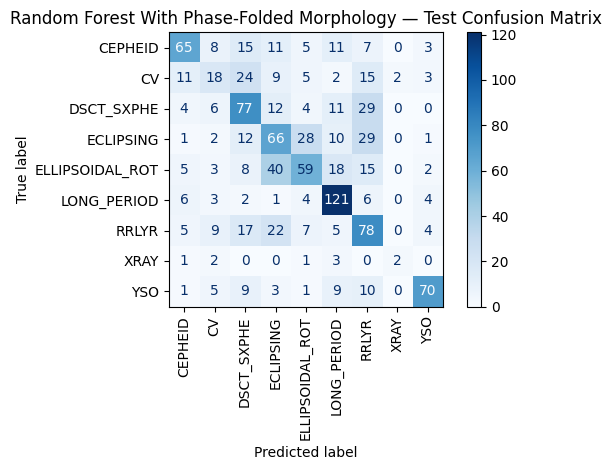

In [23]:

# ============================================================
# Phase-folded morphology model diagnostics
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

print("Random Forest with phase-folded morphology — test classification report:")
print(classification_report(yTestPhase, RandomForestWithPhaseTestPred, zero_division=0))

PhaseLabels = sorted(yTestPhase.unique())

ConfusionMatrixDisplay.from_predictions(
    yTestPhase,
    RandomForestWithPhaseTestPred,
    labels=PhaseLabels,
    xticks_rotation=90,
    cmap="Blues",
)

plt.title("Random Forest With Phase-Folded Morphology — Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [24]:

# ============================================================
# Feature importance for phase-folded morphology model
# ============================================================

RfWithPhaseClassifier = RandomForestWithPhaseModel.named_steps["model"]

PhaseImportanceDf = pd.DataFrame({
    "Feature": FeatureColumnsWithPhase,
    "Importance": RfWithPhaseClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

print("Top 30 Random Forest feature importances with phase morphology features:")
display(PhaseImportanceDf.head(30))

print("Phase morphology features only:")
display(
    PhaseImportanceDf[PhaseImportanceDf["Feature"].isin(UsablePhaseFeatureColumns)]
    .sort_values("Importance", ascending=False)
)


Top 30 Random Forest feature importances with phase morphology features:


,Feature,Importance
6,TimeSpanDays,0.028784
33,EtaVonNeumann,0.025330
5,CadenceCount,0.022709
3,OriginalFluxStd,0.021078
4,OriginalFluxSnr,0.020188
34,MaxAbsSlope,0.018363
13,FluxMin,0.017771
24,FluxAmplitude,0.017515
35,MedianAbsSuccessiveDiff,0.017398
79,PhaseDipSharpness,0.015944


Phase morphology features only:


,Feature,Importance
79,PhaseDipSharpness,0.015944
80,PhaseFourierA1,0.015110
73,PhaseAmplitude95To5,0.014493
74,PhaseMedianAbsDiff,0.014384
76,PhaseSkewness,0.013859
78,PhasePeakSharpness,0.013291
75,PhaseMaxAbsDiff,0.012365
84,PhaseFourierA3OverA1,0.012002
83,PhaseFourierA2OverA1,0.011893
77,PhaseKurtosis,0.011689



### Phase-Folded Morphology Interpretation Guide

After running this section, compare the model with and without phase-folded morphology features.

Important questions:

1. **Does test accuracy improve?**
   - If yes, folded morphology adds useful information beyond period and flux statistics.
   - If no, current morphology features may be too simple, too noisy, or limited by incorrect period estimates.

2. **Does balanced accuracy improve?**
   - This is especially important because balanced accuracy measures whether minority classes improve rather than only dominant classes.

3. **Do specific confusion pairs improve?**
   - Important pairs include:
     - `ECLIPSING` vs `ELLIPSOIDAL_ROT`
     - `RRLYR` vs `DSCT_SXPHE`
     - `CV` vs pulsating/periodic classes

4. **Do phase morphology features appear in feature importance?**
   - If phase features become important, this supports the astrophysical idea that light-curve shape contains class-discriminative information.
   - If they remain weak, the current representation may not yet capture the relevant morphology, or period estimates may need improvement first.

### Scientific Framing

This experiment asks whether the model can move from using mostly global variability descriptors toward using more physically meaningful folded light-curve shape information.

A positive result would strengthen the astrophysics narrative by showing that variable star families are separated not only by period and amplitude, but also by phase-folded morphology.



## Phase-Folded Morphology Analysis Conclusion

### Summary of Results

The phase-folded morphology experiment compared the Random Forest model with and without the newly added folded-shape features.

| Model | Validation Accuracy | Validation Balanced Accuracy | Test Accuracy | Test Balanced Accuracy |
|---|---:|---:|---:|---:|
| RF without phase morphology | 0.523 | 0.461 | 0.519 | 0.478 |
| RF with phase morphology | 0.518 | 0.469 | 0.521 | 0.480 |

The overall performance improvement was very small:

- Test accuracy changed from approximately **0.519** to **0.521**
- Test balanced accuracy changed from approximately **0.478** to **0.480**

Therefore, the addition of simple phase-folded morphology features did **not** substantially improve classification accuracy.

---

### Important Interpretation

Although the accuracy improvement was marginal, the morphology features were still selected by the Random Forest as informative predictors.

Several phase-folded morphology features appeared among the important features, including:

- `PhaseDipSharpness`
- `PhaseFourierA1`
- `PhaseAmplitude95To5`
- `PhaseMedianAbsDiff`
- `PhaseSkewness`
- `PhasePeakSharpness`

This indicates that the model does recognize folded light-curve shape information as useful.

Therefore, the correct interpretation is **not** that morphology is irrelevant.

A more accurate conclusion is:

> Phase-folded morphology contains astrophysically meaningful information, but much of that information overlaps with what is already captured by existing Lomb–Scargle harmonic features, amplitude features, and global variability statistics.

---

### Astrophysical Meaning

The important morphology features have clear physical interpretations.

| Feature | Possible Astrophysical Meaning |
|---|---|
| `PhaseDipSharpness` | sharp eclipse dips, outburst-like behavior, or steep pulsation features |
| `PhaseSkewness` | asymmetric pulsation shapes such as RR Lyrae or Cepheid-like morphology |
| `PhaseFourierA1` | dominant folded waveform structure and harmonic shape |
| `PhaseAmplitude95To5` | folded light-curve amplitude after phase alignment |
| `PhaseMedianAbsDiff` | local smoothness or irregularity in folded phase space |
| `PhasePeakSharpness` | narrow maxima or sharply peaked variability cycles |

These features are physically meaningful because many variable star families are distinguished not only by period and amplitude, but also by light-curve shape after folding by the period.

Examples include:

- RR Lyrae stars with asymmetric pulsation profiles
- Eclipsing binaries with sharp eclipse dips
- Ellipsoidal rotators with smoother double-wave modulation
- CV and YSO systems with more irregular or stochastic morphology

---

### Why Accuracy Did Not Improve Much

The small performance gain suggests that the current feature set already captures much of the recoverable morphology information indirectly.

Before adding explicit phase-folded morphology features, the model already included:

- Lomb–Scargle best period
- multiple LS period and frequency peaks
- LS power and false-alarm-probability features
- amplitude statistics
- flux skewness and kurtosis
- percentile/tail features
- local variability features such as `EtaVonNeumann` and `MedianAbsSuccessiveDiff`

These features already encode significant information about waveform shape and variability structure.

Thus, the phase-folded morphology features appear to be informative but not strongly independent from the existing feature set.

---

### Relationship to Earlier Experiments

This result is consistent with two earlier findings:

1. Adding enhanced Lomb–Scargle harmonic features produced only marginal gains.
2. Conditional detrending of TESSCut light curves did not materially improve RF performance.

Together with the phase-folded morphology result, these experiments suggest that incremental feature engineering is unlikely to be the dominant bottleneck in the current classification pipeline.

Instead, the strongest limiting factors appear to be:

- provenance differences between SPOC, QLP, and TESSCut
- observational quality and systematic effects
- TESSCut extraction and aperture limitations
- possible source-association uncertainty
- intrinsic overlap between physically similar variability classes

---

### Final Scientific Conclusion

The phase-folded morphology experiment supports a nuanced conclusion.

It shows that folded light-curve morphology is astrophysically meaningful and is used by the model, but it does not substantially improve overall classification performance beyond the existing feature set.

This strengthens the broader project conclusion:

> The major limitation in the current TESS variable-star classification pipeline is not simply the absence of additional hand-engineered features. Instead, differences in provenance, preprocessing, observational quality, and intrinsic astrophysical class overlap appear to have a larger impact on classification performance.

Therefore, the main scientific contribution of the project is not the discovery of a superior feature set, but the demonstration that TESS light-curve provenance affects which astrophysical variability signatures remain recoverable for machine-learning classification.



## Step 18 — Provenance-Specific Feature Importance Comparison

### Motivation

The previous sections compared Random Forest performance across provenance-specific datasets:

- SPOC-only
- QLP-only
- TESSCut-only

However, accuracy alone does not explain *why* the models behave differently. This section asks a more astrophysical question:

> Do Random Forest models trained on different provenance sources rely on different kinds of variability information?

This is important because different TESS light-curve products may preserve different aspects of the underlying astrophysical signal. For example, one provenance source may preserve detailed periodic or harmonic structure, while another may force the model to rely more heavily on coarse amplitude, slope, cadence, or statistical variability descriptors.

This section compares feature importance across separately trained SPOC-only, QLP-only, and TESSCut-only Random Forest models using two methods:

1. **Random Forest built-in feature importance**
2. **Permutation importance**

The goal is not simply to rank features, but to determine whether provenance changes the type of astrophysical information used for classification.


In [25]:

# ============================================================
# Provenance-specific Random Forest models + feature importance comparison
# ============================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Select the feature set for this comparison
# ------------------------------------------------------------
# If phase-folded morphology has already been computed, use the final feature set
# with phase morphology. Otherwise fall back to the base feature set.
if (
    "FeatureColumnsWithPhase" in globals()
    and "TrainWithPhaseDf" in globals()
    and "ValWithPhaseDf" in globals()
    and "TestWithPhaseDf" in globals()
):
    ProvenanceComparisonDfForTraining = pd.concat(
        [
            TrainWithPhaseDf.copy(),
            ValWithPhaseDf.copy(),
            TestWithPhaseDf.copy(),
        ],
        ignore_index=True,
    )
    ProvenanceComparisonFeatureColumns = FeatureColumnsWithPhase
    print("Using final feature set including phase-folded morphology features.")
else:
    ProvenanceComparisonDfForTraining = ModelDf.copy()
    ProvenanceComparisonFeatureColumns = FeatureColumns
    print("Using base feature set without phase-folded morphology features.")


# ------------------------------------------------------------
# 2. Identify provenance column
# ------------------------------------------------------------
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]

ProvenanceColumn = None
for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in ProvenanceComparisonDfForTraining.columns:
        ProvenanceColumn = CandidateColumn
        break

if ProvenanceColumn is None:
    raise KeyError(
        "Could not find a provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

print(f"Using provenance column: {ProvenanceColumn}")


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def train_provenance_rf_model(
    InputDf,
    ProvenanceName,
    FeatureColumnsForModel,
    TargetColumnName,
    ProvenanceColumnName,
    random_state=42,
    test_size=0.30,
):
    """Train a provenance-specific RF model and return model/split/results."""

    SourceDf = InputDf[InputDf[ProvenanceColumnName] == ProvenanceName].copy()

    if SourceDf.empty:
        raise ValueError(f"No rows found for provenance: {ProvenanceName}")

    ClassCounts = SourceDf[TargetColumnName].value_counts().sort_index()

    # Stratified splitting requires at least two examples per class.
    KeepClasses = ClassCounts[ClassCounts >= 2].index
    DroppedClasses = ClassCounts[ClassCounts < 2]

    if len(DroppedClasses) > 0:
        print(f"\n{ProvenanceName}: dropping classes with fewer than 2 samples before stratified split:")
        display(DroppedClasses)

    SourceDf = SourceDf[SourceDf[TargetColumnName].isin(KeepClasses)].copy()

    if SourceDf[TargetColumnName].nunique() < 2:
        raise ValueError(
            f"{ProvenanceName}: fewer than two classes remain after filtering; "
            "cannot train classifier."
        )

    X = SourceDf[FeatureColumnsForModel]
    y = SourceDf[TargetColumnName]

    XTrainProv, XTestProv, yTrainProv, yTestProv = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    Model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state,
            )),
        ]
    )

    Model.fit(XTrainProv, yTrainProv)

    TrainPred = Model.predict(XTrainProv)
    TestPred = Model.predict(XTestProv)

    AccuracyDf = pd.DataFrame([
        {
            "Provenance": ProvenanceName,
            "split": "train",
            "accuracy": accuracy_score(yTrainProv, TrainPred),
            "balanced_accuracy": balanced_accuracy_score(yTrainProv, TrainPred),
            "sample_count": len(yTrainProv),
        },
        {
            "Provenance": ProvenanceName,
            "split": "test",
            "accuracy": accuracy_score(yTestProv, TestPred),
            "balanced_accuracy": balanced_accuracy_score(yTestProv, TestPred),
            "sample_count": len(yTestProv),
        },
    ])

    return {
        "model": Model,
        "x_train": XTrainProv,
        "x_test": XTestProv,
        "y_train": yTrainProv,
        "y_test": yTestProv,
        "test_pred": TestPred,
        "accuracy_df": AccuracyDf,
        "class_counts": ClassCounts,
    }


def build_rf_feature_importance_df(model, feature_columns, provenance_name):
    """Return Random Forest built-in feature importance for one provenance-specific model."""
    RfEstimator = model.named_steps["model"] if hasattr(model, "named_steps") else model

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "RFImportance": RfEstimator.feature_importances_
        })
        .sort_values("RFImportance", ascending=False)
        .reset_index(drop=True)
    )


def build_permutation_importance_df(
    model,
    x_test,
    y_test,
    feature_columns,
    provenance_name,
    scoring="balanced_accuracy",
    n_repeats=10,
    random_state=42
):
    """Return permutation importance for one provenance-specific model."""
    perm_result = permutation_importance(
        model,
        x_test,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "PermutationImportanceMean": perm_result.importances_mean,
            "PermutationImportanceStd": perm_result.importances_std
        })
        .sort_values("PermutationImportanceMean", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 4. Train provenance-specific RF models
# ------------------------------------------------------------

SpocResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "SPOC",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

QlpResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "QLP",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

TessCutResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "TESSCut",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

# Expose variables using names expected by the later comparison logic.
SpocRfModel = SpocResults["model"]
QlpRfModel = QlpResults["model"]
TessCutRfModel = TessCutResults["model"]

XSpocTest = SpocResults["x_test"]
YSpocTest = SpocResults["y_test"]

XQlpTest = QlpResults["x_test"]
YQlpTest = QlpResults["y_test"]

XTessCutTest = TessCutResults["x_test"]
YTessCutTest = TessCutResults["y_test"]

ProvenanceSpecificAccuracyDf = pd.concat(
    [
        SpocResults["accuracy_df"],
        QlpResults["accuracy_df"],
        TessCutResults["accuracy_df"],
    ],
    ignore_index=True,
)

print("Provenance-specific Random Forest performance:")
display(ProvenanceSpecificAccuracyDf)


# ------------------------------------------------------------
# 5. RF built-in feature importance
# ------------------------------------------------------------

SpocFeatureImportanceDf = build_rf_feature_importance_df(
    SpocRfModel,
    ProvenanceComparisonFeatureColumns,
    "SPOC"
)

QlpFeatureImportanceDf = build_rf_feature_importance_df(
    QlpRfModel,
    ProvenanceComparisonFeatureColumns,
    "QLP"
)

TessCutFeatureImportanceDf = build_rf_feature_importance_df(
    TessCutRfModel,
    ProvenanceComparisonFeatureColumns,
    "TESSCut"
)

ProvenanceFeatureImportanceDf = pd.concat(
    [SpocFeatureImportanceDf, QlpFeatureImportanceDf, TessCutFeatureImportanceDf],
    ignore_index=True
)

print("Top RF built-in feature importances by provenance:")
display(
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Permutation importance
# ------------------------------------------------------------

SpocPermutationImportanceDf = build_permutation_importance_df(
    SpocRfModel,
    XSpocTest,
    YSpocTest,
    ProvenanceComparisonFeatureColumns,
    "SPOC",
    random_state=RandomState,
)

QlpPermutationImportanceDf = build_permutation_importance_df(
    QlpRfModel,
    XQlpTest,
    YQlpTest,
    ProvenanceComparisonFeatureColumns,
    "QLP",
    random_state=RandomState,
)

TessCutPermutationImportanceDf = build_permutation_importance_df(
    TessCutRfModel,
    XTessCutTest,
    YTessCutTest,
    ProvenanceComparisonFeatureColumns,
    "TESSCut",
    random_state=RandomState,
)

ProvenancePermutationImportanceDf = pd.concat(
    [SpocPermutationImportanceDf, QlpPermutationImportanceDf, TessCutPermutationImportanceDf],
    ignore_index=True
)

print("Top permutation importances by provenance:")
display(
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Side-by-side summaries
# ------------------------------------------------------------

TopN = 10

TopRfImportanceSummaryDf = (
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

TopPermutationImportanceSummaryDf = (
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

print("Top RF built-in feature importance comparison:")
display(TopRfImportanceSummaryDf)

print("Top permutation importance comparison:")
display(TopPermutationImportanceSummaryDf)


Using final feature set including phase-folded morphology features.
Using provenance column: Provenance
Provenance-specific Random Forest performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,SPOC,train,1.000000,1.000000,326
1,SPOC,test,0.787234,0.642442,141
2,QLP,train,1.000000,1.000000,1128
3,QLP,test,0.723140,0.421116,484
4,TESSCut,train,1.000000,1.000000,3523
5,TESSCut,test,0.443415,0.361744,1511


Top RF built-in feature importances by provenance:


,Provenance,Feature,RFImportance
0,SPOC,OriginalFluxStd,0.046819
1,SPOC,OriginalFluxSnr,0.046311
2,SPOC,LsTopPeriod2,0.028286
3,SPOC,LsTopFrequency3,0.024582
4,SPOC,LsTopFrequency2,0.024577
5,SPOC,LsTopFrequency1,0.023925
6,SPOC,LsBestPeriod,0.023551
7,SPOC,LsTopPeriod3,0.023409
8,SPOC,PhaseKurtosis,0.022971
9,SPOC,LsBestFrequency,0.022800


Top permutation importances by provenance:


,Provenance,Feature,PermutationImportanceMean,PermutationImportanceStd
0,SPOC,OriginalFluxStd,0.084446,0.018442
1,SPOC,OriginalFluxSnr,0.068778,0.016621
2,SPOC,LsTopFrequency3,0.018571,0.005512
3,SPOC,PhaseFourierA3,0.017778,0.005443
4,SPOC,LsBestFrequency,0.015676,0.007340
5,SPOC,LsBestPeriod,0.014584,0.006813
6,SPOC,FluxPercentAmplitude90To10,0.014535,0.005751
7,SPOC,FluxKurtosis,0.011533,0.007362
8,SPOC,LsPeriod2,0.011514,0.004178
9,SPOC,LsTopPeriod3,0.010714,0.002137


Top RF built-in feature importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,MedianAbsSuccessiveDiff,OriginalFluxStd,TimeSpanDays
2,PhaseMedianAbsDiff,OriginalFluxSnr,EtaVonNeumann
3,OriginalFluxSnr,LsTopPeriod2,FluxAmplitude
4,LsBestPeriod,LsTopFrequency3,CadenceCount
5,OriginalFluxStd,LsTopFrequency2,FluxMax
6,LsTopPeriod1,LsTopFrequency1,MaxAbsSlope
7,TimeSpanDays,LsBestPeriod,FluxKurtosis
8,LsBestFrequency,LsTopPeriod3,FluxMin
9,LsPeriod2,PhaseKurtosis,FluxP99


Top permutation importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,OriginalFluxSnr,OriginalFluxStd,TimeSpanDays
2,OriginalFluxStd,OriginalFluxSnr,EtaVonNeumann
3,PhaseMedianAbsDiff,LsTopFrequency3,CadenceCount
4,FluxMin,PhaseFourierA3,MedianAbsSuccessiveDiff
5,PhasePeakToTroughPhaseDelta,LsBestFrequency,PhaseMaxAbsDiff
6,LsBestFrequency,LsBestPeriod,PhasePeakPhase
7,TimeSpanDays,FluxPercentAmplitude90To10,PhaseDipSharpness
8,LsBestPeriod,FluxKurtosis,FluxPercentAmplitude90To10
9,LsTopPeriod3,LsPeriod2,FluxAmplitude



### Feature Category Comparison

Individual feature rankings are useful, but they can be noisy because many features are correlated. A more interpretable comparison is to group features by their astrophysical meaning.

This section groups features into categories such as:

- periodicity / Lomb–Scargle structure
- phase-folded morphology
- amplitude
- flux distribution
- local variability / stochasticity
- observation quality / cadence

The goal is to compare *types of information* preserved by each provenance source rather than individual feature names alone.


In [26]:

# ============================================================
# Feature category importance comparison
# ============================================================

def categorize_feature(feature_name):
    """Map a feature name into a broad astrophysical/observational category."""
    f = str(feature_name)

    if f.startswith("Phase"):
        return "Phase-folded morphology"

    if f.startswith("Ls") or "Frequency" in f or "Period" in f or "FalseAlarm" in f:
        return "Periodicity / LS structure"

    if "Amplitude" in f or f in ["FluxMax", "FluxMin"]:
        return "Amplitude / extrema"

    if (
        "Skewness" in f or
        "Kurtosis" in f or
        "Tail" in f or
        "P01" in f or
        "P05" in f or
        "P10" in f or
        "P25" in f or
        "P50" in f or
        "P75" in f or
        "P90" in f or
        "P95" in f or
        "P99" in f
    ):
        return "Flux distribution / shape"

    if (
        "EtaVonNeumann" in f or
        "SuccessiveDiff" in f or
        "MaxAbsSlope" in f or
        "Slope" in f or
        "Smoothness" in f
    ):
        return "Local variability / stochasticity"

    if (
        "Cadence" in f or
        "TimeSpan" in f or
        "Quality" in f or
        "Snr" in f or
        "SNR" in f or
        "LowSnr" in f
    ):
        return "Observation quality / cadence"

    if "FluxStd" in f or "Std" in f:
        return "Flux scatter / noise"

    return "Other"


CategoryRfImportanceDf = (
    ProvenanceFeatureImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["RFImportance"]
    .sum()
    .sort_values(["Provenance", "RFImportance"], ascending=[True, False])
)

CategoryRfImportancePivotDf = (
    CategoryRfImportanceDf
    .pivot(index="Category", columns="Provenance", values="RFImportance")
    .fillna(0)
)

print("RF built-in importance by feature category:")
display(CategoryRfImportancePivotDf)


CategoryPermutationImportanceDf = (
    ProvenancePermutationImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["PermutationImportanceMean"]
    .sum()
    .sort_values(["Provenance", "PermutationImportanceMean"], ascending=[True, False])
)

CategoryPermutationImportancePivotDf = (
    CategoryPermutationImportanceDf
    .pivot(index="Category", columns="Provenance", values="PermutationImportanceMean")
    .fillna(0)
)

print("Permutation importance by feature category:")
display(CategoryPermutationImportancePivotDf)


ProvenanceFeatureImportanceDf.to_csv(OutputDir / "provenance_rf_feature_importance.csv", index=False)
ProvenancePermutationImportanceDf.to_csv(OutputDir / "provenance_permutation_importance.csv", index=False)
CategoryRfImportancePivotDf.to_csv(OutputDir / "provenance_rf_feature_category_importance.csv")
CategoryPermutationImportancePivotDf.to_csv(OutputDir / "provenance_permutation_feature_category_importance.csv")

print("Saved provenance feature-importance comparison outputs to:")
print(OutputDir)


RF built-in importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.051342,0.063084,0.091555
Flux distribution / shape,0.147263,0.170450,0.185192
Flux scatter / noise,0.043824,0.065384,0.044678
Local variability / stochasticity,0.049940,0.043205,0.065363
Observation quality / cadence,0.068394,0.068613,0.079816
Other,0.029984,0.054005,0.039196
Periodicity / LS structure,0.362935,0.378753,0.266485
Phase-folded morphology,0.246318,0.156505,0.227715


Permutation importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.017879,0.027066,-0.009922
Flux distribution / shape,0.035189,0.039581,-0.014201
Flux scatter / noise,0.021389,0.092187,-0.003307
Local variability / stochasticity,0.017033,0.025212,0.004809
Observation quality / cadence,0.028338,0.077567,0.019304
Other,0.008754,-0.004359,-0.006125
Periodicity / LS structure,0.095759,0.121190,-0.024859
Phase-folded morphology,0.071003,0.075000,-0.007679


Saved provenance feature-importance comparison outputs to:
/data/projects/TESS-research/ml_analytics/output



### Provenance-Specific Feature Importance Interpretation

This analysis should be interpreted together with the provenance-specific accuracy results.

If the top features and feature-category totals differ substantially across SPOC, QLP, and TESSCut models, that supports the idea that provenance does not merely change overall noise level. Instead, different preprocessing and extraction pipelines may change which categories of astrophysical information remain recoverable.

A scientifically meaningful pattern would be:

| Provenance Pattern | Interpretation |
|---|---|
| SPOC relies more on periodic / harmonic features | cleaner pipeline products preserve detailed periodic structure |
| QLP relies on mixed periodic and statistical features | intermediate preprocessing preserves some periodic information but less consistently |
| TESSCut relies more on amplitude, slope, cadence, or flux-distribution features | cutout-based light curves may retain coarse variability but weaken fine harmonic separability |
| Phase-folded morphology features rank highly across models | folded light-curve shape contains real astrophysical information |
| Observation-quality features rank highly | model performance is partly limited by data quality and sampling effects |

Important caution: provenance-specific datasets differ not only in preprocessing pipeline, but also in sample size and class distribution. Therefore, feature-importance differences should be interpreted as evidence of **provenance-associated information shifts**, not as a perfectly isolated causal effect of the pipeline alone.

Overall, this section helps connect the machine-learning results to the central astrophysical question:

> How do different TESS light-curve provenance sources affect the recoverability of variable-star signatures?



## Step 19 — Provenance-Specific Feature Importance Interpretation and SPOC Diagnostic Follow-Up

### Confirmation of Provenance-Specific Feature Importance Result

The Step 18 provenance-specific feature-importance comparison supports one of the central conclusions of the project:

> Different TESS light-curve provenance sources preserve different categories of astrophysical variability information, causing Random Forest classifiers to rely on substantially different feature groups for variable-star classification.

This conclusion is stronger than a simple accuracy comparison. Accuracy shows that SPOC, QLP, and TESSCut perform differently; feature importance helps explain *why* they perform differently.

---

### SPOC-only Model

The SPOC-only model relies strongly on:

- `OriginalFluxStd`
- `OriginalFluxSnr`
- Lomb–Scargle period and frequency features
- harmonic structure features
- some phase morphology features

This suggests that SPOC light curves preserve high-quality variability information and detailed periodic/harmonic structure that remain useful for classification.

---

### QLP-only Model

The QLP-only model shows a more mixed pattern, using:

- local variability features
- phase-morphology features
- signal-to-noise / flux-scatter features
- selected LS period features
- observation-baseline features such as `TimeSpanDays`

This suggests that QLP preserves some periodic structure, but the model relies more on a mixture of morphology, local variability, and signal-quality descriptors than in the SPOC-only case.

---

### TESSCut-only Model

The TESSCut-only model relies more heavily on:

- `TimeSpanDays`
- `CadenceCount`
- `EtaVonNeumann`
- `FluxAmplitude`
- `FluxMax`
- `MaxAbsSlope`
- `FluxSkewness`
- `FluxKurtosis`

Detailed LS/harmonic features are less dominant. This suggests that TESSCut classification depends more on coarse statistical variability, cadence, slope, and flux-distribution descriptors rather than clean periodic/harmonic structure.

---

### Scientific Interpretation

The Step 18 results suggest that provenance affects not only the overall classification accuracy, but also the type of astrophysical information available to the classifier.

| Provenance | Dominant Information Used by RF |
|---|---|
| SPOC | flux scatter/SNR plus periodic and harmonic structure |
| QLP | mixed local variability, morphology, SNR, and some periodic structure |
| TESSCut | cadence, amplitude, slope, stochasticity, and flux-distribution descriptors |

This supports the project’s broader scientific interpretation:

> Different light-curve provenance sources are associated with different recoverable astrophysical variability signatures.

---

### Important Caution

The safest wording is not that provenance alone causally determines feature importance. The provenance-specific subsets also differ in:

- sample size
- class distribution
- observational availability
- preprocessing pipeline
- possible TESSCut source-association uncertainty

Therefore, the most defensible conclusion is:

> The observed provenance-specific datasets exhibit substantially different feature-importance patterns, consistent with the interpretation that different light-curve products preserve different categories of astrophysical variability information.

---

### Unexpected Observation: `OriginalFluxStd` and `OriginalFluxSnr`

One unexpected result is that `OriginalFluxStd` and `OriginalFluxSnr` ranked very highly for the SPOC-only model.

This deserves follow-up because these features may represent:

1. real astrophysical variability strength,
2. data quality / noise behavior,
3. class-distribution effects,
4. or a combination of astrophysical and observational information.

The diagnostic code below investigates whether these two features differ strongly by class, correlate with amplitude or quality features, or are associated with correct versus incorrect SPOC predictions.


In [27]:

# ============================================================
# Step 19 Diagnostic: OriginalFluxStd and OriginalFluxSnr in SPOC
# ============================================================

DiagnosticFeatures = [
    col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
    if col in globals().get("ProvenanceComparisonDfForTraining", ModelDf).columns
]

if len(DiagnosticFeatures) == 0:
    raise KeyError(
        "Neither OriginalFluxStd nor OriginalFluxSnr exists in the current dataframe."
    )

# Use the final dataframe from Step 18 if available; otherwise fall back to ModelDf.
DiagnosticBaseDf = globals().get("ProvenanceComparisonDfForTraining", ModelDf).copy()

# Identify provenance column robustly.
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]
DiagnosticProvenanceColumn = None

for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in DiagnosticBaseDf.columns:
        DiagnosticProvenanceColumn = CandidateColumn
        break

if DiagnosticProvenanceColumn is None:
    raise KeyError(
        "Could not find provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

SpocDiagnosticDf = DiagnosticBaseDf[
    DiagnosticBaseDf[DiagnosticProvenanceColumn] == "SPOC"
].copy()

print(f"SPOC diagnostic row count: {len(SpocDiagnosticDf)}")
print(f"Using provenance column: {DiagnosticProvenanceColumn}")
print(f"Diagnostic features available: {DiagnosticFeatures}")


# ------------------------------------------------------------
# 1. Distribution of OriginalFluxStd / OriginalFluxSnr by class
# ------------------------------------------------------------

SpocFeatureByClassDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .agg(["count", "mean", "median", "std"])
)

print("OriginalFluxStd / OriginalFluxSnr by class within SPOC:")
display(SpocFeatureByClassDf)


# ------------------------------------------------------------
# 2. Correct-vs-incorrect diagnostic if SPOC model variables exist
# ------------------------------------------------------------

RequiredSpocObjects = ["SpocRfModel", "XSpocTest", "YSpocTest"]
MissingSpocObjects = [name for name in RequiredSpocObjects if name not in globals()]

if MissingSpocObjects:
    print(
        "Skipping correct-vs-incorrect SPOC prediction diagnostic because "
        f"these objects are missing: {MissingSpocObjects}"
    )
else:
    SpocTestPredictionDf = XSpocTest.copy()
    SpocTestPredictionDf[TargetColumn] = YSpocTest
    SpocTestPredictionDf["Prediction"] = SpocRfModel.predict(XSpocTest)
    SpocTestPredictionDf["Correct"] = (
        SpocTestPredictionDf[TargetColumn] == SpocTestPredictionDf["Prediction"]
    )

    CorrectComparisonFeatures = [
        col for col in DiagnosticFeatures
        if col in SpocTestPredictionDf.columns
    ]

    if CorrectComparisonFeatures:
        SpocCorrectVsIncorrectDf = (
            SpocTestPredictionDf
            .groupby("Correct")[CorrectComparisonFeatures]
            .agg(["count", "mean", "median", "std"])
        )

        print("SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:")
        display(SpocCorrectVsIncorrectDf)
    else:
        print("Diagnostic features are not present in XSpocTest; skipping correct-vs-incorrect comparison.")


# ------------------------------------------------------------
# 3. Correlation with related amplitude / quality / variability features
# ------------------------------------------------------------

CandidateCorrelationFeatures = [
    "OriginalFluxStd",
    "OriginalFluxSnr",
    "FluxAmplitude",
    "FluxPercentAmplitude95To5",
    "PhaseAmplitude95To5",
    "EtaVonNeumann",
    "MedianAbsSuccessiveDiff",
    "LsMaxPower",
    "LsFalseAlarmProbability",
    "LsLogFalseAlarmProbability",
    "CadenceCount",
    "TimeSpanDays",
]

AvailableCorrelationFeatures = [
    col for col in CandidateCorrelationFeatures
    if col in SpocDiagnosticDf.columns
]

if len(AvailableCorrelationFeatures) >= 2:
    SpocCorrelationDf = SpocDiagnosticDf[AvailableCorrelationFeatures].corr(
        method="spearman"
    )

    print("Spearman correlation among SPOC diagnostic / variability / quality features:")
    display(SpocCorrelationDf)

    ImportantCorrelationRows = [
        col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
        if col in SpocCorrelationDf.index
    ]

    if ImportantCorrelationRows:
        print("Correlations involving OriginalFluxStd / OriginalFluxSnr:")
        display(
            SpocCorrelationDf
            .loc[ImportantCorrelationRows]
            .T
            .sort_values(ImportantCorrelationRows[0], ascending=False)
        )
else:
    print("Not enough related features available for correlation analysis.")


# ------------------------------------------------------------
# 4. Class-level median diagnostic features and sample counts
# ------------------------------------------------------------

SpocClassSupportDf = (
    SpocDiagnosticDf[TargetColumn]
    .value_counts()
    .rename_axis(TargetColumn)
    .reset_index(name="SpocSampleCount")
)

SpocClassFeatureSummaryDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .median()
    .reset_index()
    .merge(SpocClassSupportDf, on=TargetColumn, how="left")
    .sort_values("SpocSampleCount", ascending=False)
)

print("SPOC class-level median diagnostic features and sample count:")
display(SpocClassFeatureSummaryDf)


SPOC diagnostic row count: 467
Using provenance column: Provenance
Diagnostic features available: ['OriginalFluxStd', 'OriginalFluxSnr']
OriginalFluxStd / OriginalFluxSnr by class within SPOC:


OriginalFluxStd                               OriginalFluxSnr                                    
                          count      mean    median       std           count        mean      median         std
family                                                                                                           
CEPHEID                      29  0.219411  0.143435  0.257213              29    7.146100    6.971783    3.607944
CV                           66  2.250291  0.830834  3.577226              66    3.166877    1.203881    7.814282
DSCT_SXPHE                   34  0.062919  0.036345  0.093691              34  157.236183   27.514376  209.506255
ECLIPSING                     8  0.076258  0.073998  0.038755               8   17.563127   13.533204   10.809281
ELLIPSOIDAL_ROT             122  0.011876  0.008436  0.016829             122  199.692317  118.541635  308.181588
LONG_PERIOD                  90  0.007577  0.004732  0.009812              90  347.502894  211.438228  331.150808
RRLYR                         3  0.132968  0.097922  0.086405               3    9.634506   10.212171    5.048819
XRAY                         24  1.110875  0.116472  2.000766              24  189.748539   15.088963  537.404069
YSO                          91  0.171095  0.076004  0.302599              91   40.068532   13.157288   76.906176

SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:


OriginalFluxStd                               OriginalFluxSnr                                   
                  count      mean    median       std           count        mean     median         std
Correct                                                                                                 
False                30  0.784992  0.080625  1.611204              30  155.973785  12.431204  267.427284
True                111  0.362358  0.016188  1.630459             111  153.224363  61.772928  303.156293

Spearman correlation among SPOC diagnostic / variability / quality features:


,OriginalFluxStd,OriginalFluxSnr,FluxAmplitude,FluxPercentAmplitude95To5,PhaseAmplitude95To5,EtaVonNeumann,MedianAbsSuccessiveDiff,LsMaxPower,LsFalseAlarmProbability,LsLogFalseAlarmProbability,CadenceCount,TimeSpanDays
OriginalFluxStd,1.000000,-1.000000,-0.012971,0.207766,-0.247540,0.211001,0.232802,-0.236910,0.323073,0.323073,0.002768,-0.227989
OriginalFluxSnr,-1.000000,1.000000,0.012971,-0.207766,0.247540,-0.211001,-0.232802,0.236910,-0.323073,-0.323073,-0.002768,0.227989
FluxAmplitude,-0.012971,0.012971,1.000000,0.158153,-0.518272,0.687990,0.553419,-0.763410,0.241481,0.241481,0.429626,0.277587
FluxPercentAmplitude95To5,0.207766,-0.207766,0.158153,1.000000,-0.189436,0.276563,0.278030,-0.388563,0.247742,0.247742,0.046315,-0.018729
PhaseAmplitude95To5,-0.247540,0.247540,-0.518272,-0.189436,1.000000,-0.718514,-0.709821,0.737866,-0.588594,-0.588594,-0.169287,0.034652
EtaVonNeumann,0.211001,-0.211001,0.687990,0.276563,-0.718514,1.000000,0.945100,-0.746879,0.589443,0.589443,0.144583,-0.083739
MedianAbsSuccessiveDiff,0.232802,-0.232802,0.553419,0.278030,-0.709821,0.945100,1.000000,-0.653106,0.590557,0.590557,0.010043,-0.224830
LsMaxPower,-0.236910,0.236910,-0.763410,-0.388563,0.737866,-0.746879,-0.653106,1.000000,-0.613907,-0.613907,-0.213745,-0.087251
LsFalseAlarmProbability,0.323073,-0.323073,0.241481,0.247742,-0.588594,0.589443,0.590557,-0.613907,1.000000,1.000000,-0.147758,-0.199505
LsLogFalseAlarmProbability,0.323073,-0.323073,0.241481,0.247742,-0.588594,0.589443,0.590557,-0.613907,1.000000,1.000000,-0.147758,-0.199505


Correlations involving OriginalFluxStd / OriginalFluxSnr:


,OriginalFluxStd,OriginalFluxSnr
OriginalFluxStd,1.000000,-1.000000
LsFalseAlarmProbability,0.323073,-0.323073
LsLogFalseAlarmProbability,0.323073,-0.323073
MedianAbsSuccessiveDiff,0.232802,-0.232802
EtaVonNeumann,0.211001,-0.211001
FluxPercentAmplitude95To5,0.207766,-0.207766
CadenceCount,0.002768,-0.002768
FluxAmplitude,-0.012971,0.012971
TimeSpanDays,-0.227989,0.227989
LsMaxPower,-0.236910,0.236910


SPOC class-level median diagnostic features and sample count:


,family,OriginalFluxStd,OriginalFluxSnr,SpocSampleCount
4,ELLIPSOIDAL_ROT,0.008436,118.541635,122
8,YSO,0.076004,13.157288,91
5,LONG_PERIOD,0.004732,211.438228,90
1,CV,0.830834,1.203881,66
2,DSCT_SXPHE,0.036345,27.514376,34
0,CEPHEID,0.143435,6.971783,29
7,XRAY,0.116472,15.088963,24
3,ECLIPSING,0.073998,13.533204,8
6,RRLYR,0.097922,10.212171,3



### Interpretation Guide for the SPOC `OriginalFluxStd` / `OriginalFluxSnr` Diagnostic

Use the diagnostic outputs as follows:

- If `OriginalFluxStd` and `OriginalFluxSnr` differ strongly by variable-star family, they likely encode real astrophysical variability strength.
- If they are strongly associated with correct predictions, they may help identify high-quality or high-amplitude cases that are easier to classify.
- If they correlate strongly with amplitude features, they are probably acting partly as astrophysical variability-amplitude proxies.
- If they correlate strongly with quality/cadence features, they may also reflect observational quality or sampling effects.
- If they are dominated by a few high-support classes, their importance may partly reflect class distribution.

The most scientifically careful interpretation is that `OriginalFluxStd` and `OriginalFluxSnr` likely combine astrophysical and observational information. They should therefore be discussed as informative variability/quality descriptors, rather than as purely physical stellar parameters.



### Update: Origin of `OriginalFluxStd` and `OriginalFluxSnr`

The high importance of `OriginalFluxStd` and `OriginalFluxSnr` in the SPOC-only model motivated a follow-up check of the upstream feature-generation logic.

The origin of these fields was traced to `tess_variable_star_categorization.ipynb`, where the relevant quantities are computed as:

```python
medianFlux = float(np.nanmedian(validFlux))
stdFlux = float(np.nanstd(validFlux))

fluxSnr = None if lowStd else float(abs(medianFlux) / stdFlux)
```

Therefore:

```text
fluxSnr = abs(fluxMedian) / fluxStd
```

This explains why `OriginalFluxStd` and `OriginalFluxSnr` show an almost perfect Spearman anti-correlation.

They are not independent features. Instead, `OriginalFluxSnr` is mathematically derived from `fluxStd` and the median flux level. If the median flux is relatively stable or normalized across a subset of light curves, then increasing `fluxStd` will almost automatically decrease `fluxSnr`.

---

### Revised Interpretation

The earlier diagnostic showed that `OriginalFluxStd` and `OriginalFluxSnr` vary substantially across variable-star families and are important for the SPOC-only Random Forest model. However, because `OriginalFluxSnr` is derived from `OriginalFluxStd`, they should not be interpreted as two independent astrophysical discoveries.

A more careful interpretation is:

> `OriginalFluxStd` and `OriginalFluxSnr` form a linked variability / signal-quality descriptor group. Their high feature importance in the SPOC-only model likely reflects the importance of flux scatter relative to baseline signal level, rather than two independent physical measurements.

This does not invalidate the SPOC feature-importance result. Instead, it clarifies that the model is strongly using a single underlying concept:

```text
relative flux scatter / variability strength
```

rather than two unrelated quantities.

---

### Scientific Meaning

In well-processed SPOC light curves, relative flux scatter can still be astrophysically meaningful because different variable-star families naturally exhibit different variability amplitudes, smoothness, and scatter properties.

However, because this descriptor also depends on measurement noise and preprocessing, it should be described cautiously as a combined astrophysical-and-observational feature.

The safest wording for the paper/notebook is:

> The SPOC-only model assigns high importance to a linked flux-scatter / signal-to-noise descriptor group (`OriginalFluxStd`, `OriginalFluxSnr`). Since `fluxSnr` is defined as `abs(fluxMedian) / fluxStd`, these features are mathematically related and should be interpreted together rather than as independent predictors. Their importance suggests that relative flux scatter is a major discriminative signal in the SPOC subset, likely combining intrinsic variability strength with observational noise behavior.

---

### Implication for Feature Importance Analysis

Because `OriginalFluxStd` and `OriginalFluxSnr` are highly redundant, future feature-importance interpretation should avoid double-counting them.

For scientific discussion, they should be grouped under a single category such as:

```text
Flux scatter / relative signal strength
```

rather than discussed separately.

This reinforces the broader conclusion that feature importance must be interpreted with awareness of feature definitions and correlations, not only model rankings.



### Final Update: Effect of `OriginalFluxStd` / `OriginalFluxSnr` Redundancy on the Provenance Conclusion

The discovery that `OriginalFluxSnr` is computed from `OriginalFluxStd` changes how these two features should be interpreted, but it does **not** weaken the main provenance conclusion.

Because:

```text
fluxSnr = abs(fluxMedian) / fluxStd
```

the two features are mathematically related. Therefore, they should not be interpreted as two independent predictors.

Instead, they should be treated as a single linked feature group:

```text
Flux scatter / relative signal-strength descriptor
```

This descriptor likely combines:

- intrinsic variability strength,
- light-curve scatter,
- baseline flux level,
- and observational noise behavior.

---

### Revised SPOC Interpretation

The earlier statement:

> The SPOC-only model ranked `OriginalFluxStd` and `OriginalFluxSnr` as the two most important features.

should be interpreted more carefully as:

> The SPOC-only model assigns high importance to a linked flux-scatter / relative signal-strength descriptor group (`OriginalFluxStd`, `OriginalFluxSnr`), together with Lomb–Scargle period and harmonic features.

This is more scientifically accurate because `OriginalFluxStd` and `OriginalFluxSnr` are not independent measurements.

---

### Does This Affect the Provenance Feature-Importance Conclusion?

No. The main conclusion remains strongly supported.

The provenance-specific models still rely on clearly different feature groups:

| Provenance | Dominant Information Used by RF |
|---|---|
| SPOC | linked flux-scatter / relative signal-strength features plus periodic and harmonic structure |
| QLP | mixed local variability, morphology, SNR/scatter, and selected periodic structure |
| TESSCut | cadence, amplitude, slope, stochasticity, and flux-distribution descriptors |

The important result is not that two separate SPOC features ranked highly. The important result is that the **overall feature-importance pattern differs substantially across provenance-specific models**.

In particular:

- SPOC uses flux-scatter / signal-strength information together with LS period and harmonic structure.
- QLP uses a mixed feature set involving local variability, morphology, signal strength, and some periodicity.
- TESSCut relies much more strongly on cadence, amplitude, slope, stochasticity, and broad flux-distribution statistics.

Therefore, the redundancy between `OriginalFluxStd` and `OriginalFluxSnr` does not invalidate the provenance conclusion. It only improves the precision of the interpretation.

---

### Final Provenance Feature-Importance Claim

The most scientifically defensible conclusion is:

> The observed provenance-specific datasets exhibit substantially different feature-importance patterns. These differences are consistent with the interpretation that different TESS light-curve products preserve different categories of recoverable astrophysical variability information.

This wording is strong but appropriately cautious.

It avoids overclaiming that provenance alone is the sole cause, because class distribution, sample size, source association uncertainty, and extraction differences may also contribute. However, the combined accuracy, confusion-matrix, and feature-importance evidence still strongly supports the conclusion that provenance is a major factor shaping Random Forest classification behavior.
